In [29]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score,
    log_loss, matthews_corrcoef, cohen_kappa_score
)
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_class_weight

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Boosting Libraries
import xgboost as xgb
from catboost import CatBoostClassifier, Pool

# Suppress CatBoost output
import logging
logging.getLogger("catboost").setLevel(logging.WARNING)


In [30]:
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
COLORS = {"XGBoost": "#E53935", "CatBoost": "#1E88E5", "AdaBoost": "#43A047"}
PASTEL  = {"XGBoost": "#FFCDD2", "CatBoost": "#BBDEFB", "AdaBoost": "#C8E6C9"}

print("=" * 65)
print("   BOOSTING ENSEMBLE MODEL COMPARISON — FULL PIPELINE")
print("=" * 65)

   BOOSTING ENSEMBLE MODEL COMPARISON — FULL PIPELINE



[1/8] Loading & Exploring Dataset ...
  Dataset shape : (737, 15)
  Columns       : ['subject', 'product_id', 'product_name', 'bought', 'familiarity', 'brand', 'discount', 'frequent option', 'like', 'nearest alternative', 'need', 'other', 'price', 'product combination', 'type']

  Target Distribution:
bought
1    429
0    308

  Class Balance Ratio: 0.72 (0:1)

  Missing Values:
Series([], )


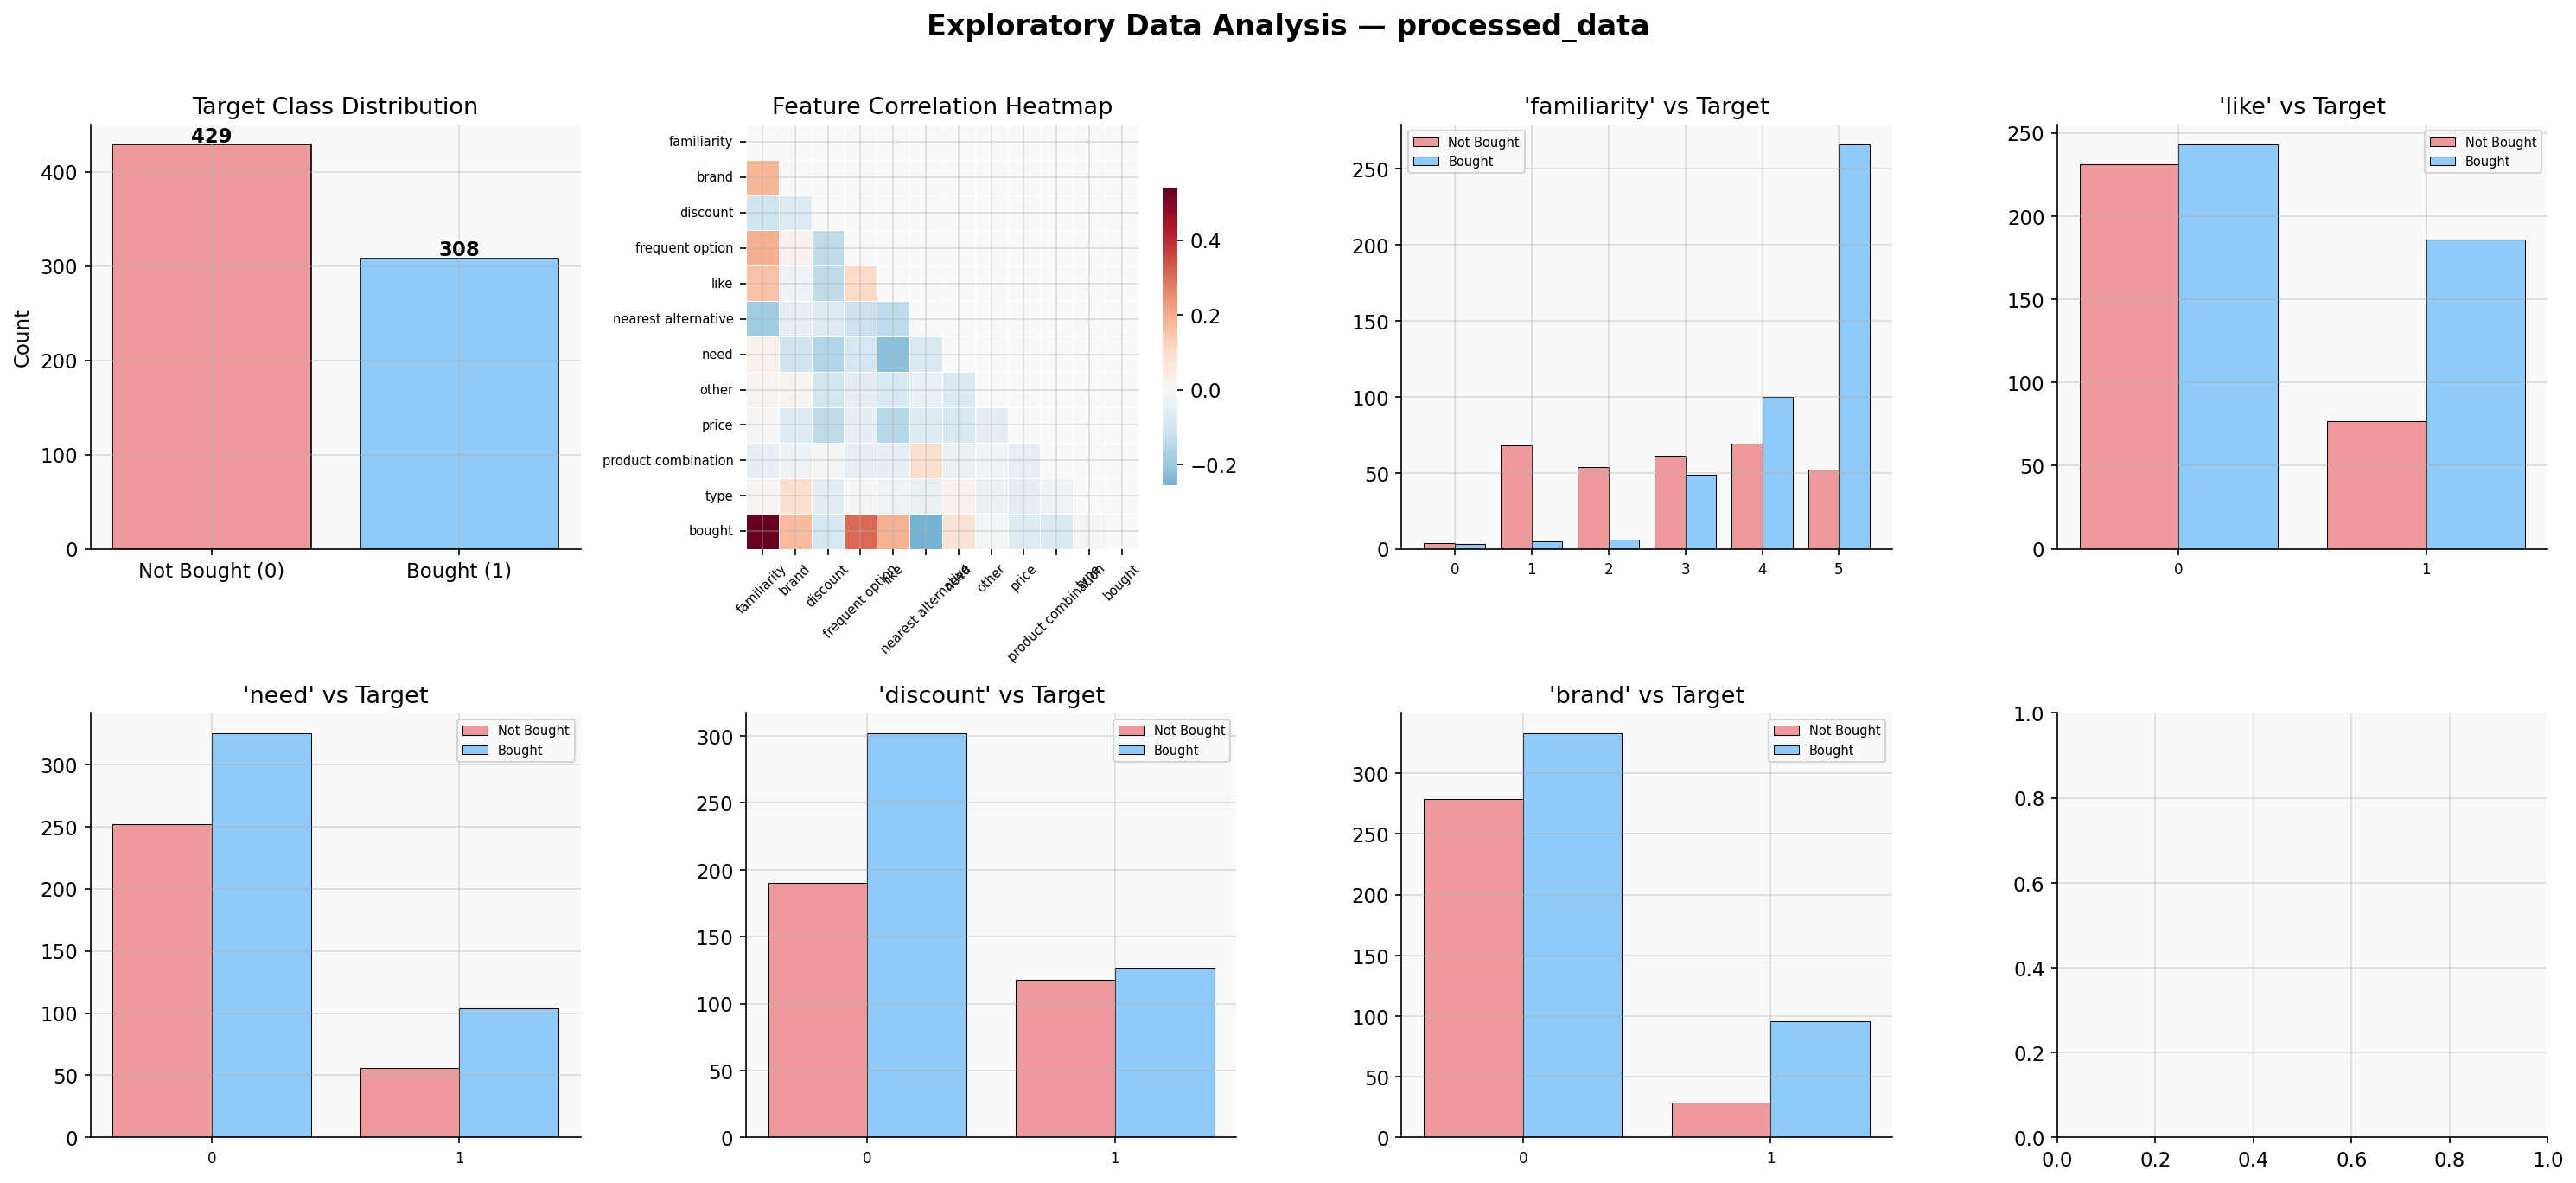

  ✓ EDA figure saved: eda_analysis.png


In [32]:
print("\n[1/8] Loading & Exploring Dataset ...")

# ── Change this path if running on Kaggle ──
DATA_PATH = "/kaggle/input/datasets/kashishrana1233/van-123/processed_data.csv"
# If running locally:
# DATA_PATH = "processed_data.csv"

df = pd.read_csv(DATA_PATH)

print(f"  Dataset shape : {df.shape}")
print(f"  Columns       : {df.columns.tolist()}")
print(f"\n  Target Distribution:\n{df['bought'].value_counts().to_string()}")
print(f"\n  Class Balance Ratio: {df['bought'].value_counts()[0]/df['bought'].value_counts()[1]:.2f} (0:1)")
print(f"\n  Missing Values:\n{df.isnull().sum()[df.isnull().sum()>0].to_string() or '  None'}")

# ─── EDA Figure ───
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle("Exploratory Data Analysis — processed_data", fontsize=16, fontweight="bold", y=1.01)

numeric_cols = ['familiarity','brand','discount','frequent option',
                'like','nearest alternative','need','other','price',
                'product combination','type']
TARGET = "bought"

# Class distribution
ax = axes[0, 0]
counts = df[TARGET].value_counts()
bars = ax.bar(["Not Bought (0)", "Bought (1)"], counts.values, color=["#EF9A9A","#90CAF9"], edgecolor="black", linewidth=0.8)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, str(count),
            ha="center", fontsize=11, fontweight="bold")
ax.set_title("Target Class Distribution")
ax.set_ylabel("Count")

# Correlation heatmap
ax = axes[0, 1]
corr = df[numeric_cols + [TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, cmap="RdBu_r", center=0, mask=mask,
            linewidths=0.3, annot=False, cbar_kws={"shrink": 0.7})
ax.set_title("Feature Correlation Heatmap")
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)

# Top features vs target
for idx, col in enumerate(['familiarity','like','need','discount','brand']):
    r, c = divmod(idx + 2, 4)
    ax = axes[r, c]
    bought_1 = df[df[TARGET]==1][col].value_counts().sort_index()
    bought_0 = df[df[TARGET]==0][col].value_counts().sort_index()
    all_vals = sorted(set(bought_0.index) | set(bought_1.index))
    x = np.arange(len(all_vals))
    ax.bar(x - 0.2, [bought_0.get(v, 0) for v in all_vals], 0.4,
           label="Not Bought", color="#EF9A9A", edgecolor="black", linewidth=0.5)
    ax.bar(x + 0.2, [bought_1.get(v, 0) for v in all_vals], 0.4,
           label="Bought", color="#90CAF9", edgecolor="black", linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(all_vals, fontsize=8)
    ax.set_title(f"'{col}' vs Target")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("eda_analysis.png", bbox_inches="tight", dpi=150)
plt.show()
print("  ✓ EDA figure saved: eda_analysis.png")


In [33]:
# ─────────────────────────────────────────────
# SECTION 4 ─ Preprocessing
# ─────────────────────────────────────────────
print("\n[2/8] Preprocessing ...")

# Drop non-numeric / ID columns
DROP_COLS = ['subject', 'product_name', 'product_id']
df_clean = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

FEATURES = [c for c in df_clean.columns if c != TARGET]
X = df_clean[FEATURES].copy()
y = df_clean[TARGET].copy()

print(f"  Feature columns ({len(FEATURES)}): {FEATURES}")
print(f"  Target         : {TARGET}")


[2/8] Preprocessing ...
  Feature columns (11): ['familiarity', 'brand', 'discount', 'frequent option', 'like', 'nearest alternative', 'need', 'other', 'price', 'product combination', 'type']
  Target         : bought


In [34]:
# Train-Test Split (stratified)
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\n  Train size  : {X_train_raw.shape[0]}")
print(f"  Test  size  : {X_test.shape[0]}")
print(f"  Train class dist: {Counter(y_train_raw)}")
print(f"  Test  class dist: {Counter(y_test)}")

# ─────────────────────────────────────────────
# SECTION 5 ─ Handle Class Imbalance with SMOTE
# ─────────────────────────────────────────────
print("\n[3/8] Balancing Classes with SMOTE ...")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print(f"  Before SMOTE: {Counter(y_train_raw)}")
print(f"  After  SMOTE: {Counter(y_train)}")

# Compute class weights (used by AdaBoost internally via sample_weight)
classes = np.array([0, 1])
class_weights = compute_class_weight("balanced", classes=classes, y=y_train_raw)
class_weight_dict = dict(zip(classes, class_weights))
print(f"  Class Weights: {class_weight_dict}")



  Train size  : 589
  Test  size  : 148
  Train class dist: Counter({1: 343, 0: 246})
  Test  class dist: Counter({1: 86, 0: 62})

[3/8] Balancing Classes with SMOTE ...
  Before SMOTE: Counter({1: 343, 0: 246})
  After  SMOTE: Counter({1: 343, 0: 343})
  Class Weights: {np.int64(0): np.float64(1.1971544715447155), np.int64(1): np.float64(0.858600583090379)}


In [44]:
# ─────────────────────────────────────────────
# SECTION 6 ─ Model Definitions (Anti-Overfitting)
# ─────────────────────────────────────────────
print("\n[4/8] Defining Models with Regularization ...")

# ── XGBoost ──
# Anti-overfitting: max_depth, min_child_weight, subsample, colsample_bytree,
#                  gamma, alpha (L1), lambda (L2), early stopping
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,                 # shallow trees → less overfit
    min_child_weight=5,          # min samples per leaf
    subsample=0.8,               # row sampling
    colsample_bytree=0.8,        # feature sampling
    gamma=1.0,                   # min loss reduction to split
    reg_alpha=0.1,               # L1 regularization
    reg_lambda=1.5,              # L2 regularization
    scale_pos_weight=class_weights[1]/class_weights[0],  # class balance
    eval_metric="logloss",
    early_stopping_rounds=30,
    random_state=42,
    use_label_encoder=False,
    verbosity=0,
)

# ── CatBoost ──
# Anti-overfitting: depth, l2_leaf_reg, border_count, early stopping
catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=4,                     # tree depth
    l2_leaf_reg=5,               # L2 regularization
    border_count=64,             # number of bins for numerical features
    bagging_temperature=0.8,     # Bayesian bootstrapping intensity
    random_strength=1.5,         # randomness for scoring splits
    class_weights={0: class_weights[0], 1: class_weights[1]},
    eval_metric="Logloss",
    early_stopping_rounds=30,
    random_seed=42,
    verbose=False,
)

# ── AdaBoost ──
# Anti-overfitting: weak learner depth=1 (stump), n_estimators, learning_rate
base_learner = DecisionTreeClassifier(
    max_depth=2,                 # shallow stump
    min_samples_leaf=5,
    class_weight=class_weight_dict,
)
adaboost_model = AdaBoostClassifier(
    estimator=base_learner,
    n_estimators=300,
    learning_rate=0.1,
    algorithm="SAMME",
    random_state=42,
)


[4/8] Defining Models with Regularization ...


In [45]:
# ─────────────────────────────────────────────
# SECTION 7 ─ Training with Loss Curves
# ─────────────────────────────────────────────
print("\n[5/8] Training Models ...")

# Validation split (from training data for loss curves)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

# ─── XGBoost ───
print("  Training XGBoost ...")
eval_set_xgb = [(X_tr, y_tr), (X_val, y_val)]
xgb_model.fit(X_tr, y_tr, eval_set=eval_set_xgb, verbose=False)
xgb_results = xgb_model.evals_result()
xgb_train_loss = xgb_results["validation_0"]["logloss"]
xgb_val_loss   = xgb_results["validation_1"]["logloss"]
best_xgb_iter  = xgb_model.best_iteration
print(f"  XGBoost best iteration: {best_xgb_iter}")

# ─── CatBoost ───
print("  Training CatBoost ...")
train_pool = Pool(X_tr, y_tr)
val_pool   = Pool(X_val, y_val)
catboost_model.fit(train_pool, eval_set=val_pool, verbose=False)
cb_evals       = catboost_model.get_evals_result()
cb_train_loss  = cb_evals["learn"]["Logloss"]
cb_val_loss    = cb_evals["validation"]["Logloss"]
best_cb_iter   = catboost_model.best_iteration_
print(f"  CatBoost best iteration: {best_cb_iter}")

# ─── AdaBoost ─ (manual staged loss curves) ───
print("  Training AdaBoost ...")
adaboost_model.fit(X_tr, y_tr)
ada_train_loss, ada_val_loss = [], []
for y_pred_staged_tr, y_pred_staged_val in zip(
    adaboost_model.staged_predict_proba(X_tr),
    adaboost_model.staged_predict_proba(X_val)
):
    ada_train_loss.append(log_loss(y_tr,  y_pred_staged_tr))
    ada_val_loss.append(  log_loss(y_val, y_pred_staged_val))
best_ada_iter = np.argmin(ada_val_loss)
print(f"  AdaBoost best iteration (min val loss): {best_ada_iter}")

# ──


[5/8] Training Models ...
  Training XGBoost ...
  XGBoost best iteration: 76
  Training CatBoost ...
  CatBoost best iteration: 45
  Training AdaBoost ...
  AdaBoost best iteration (min val loss): 76


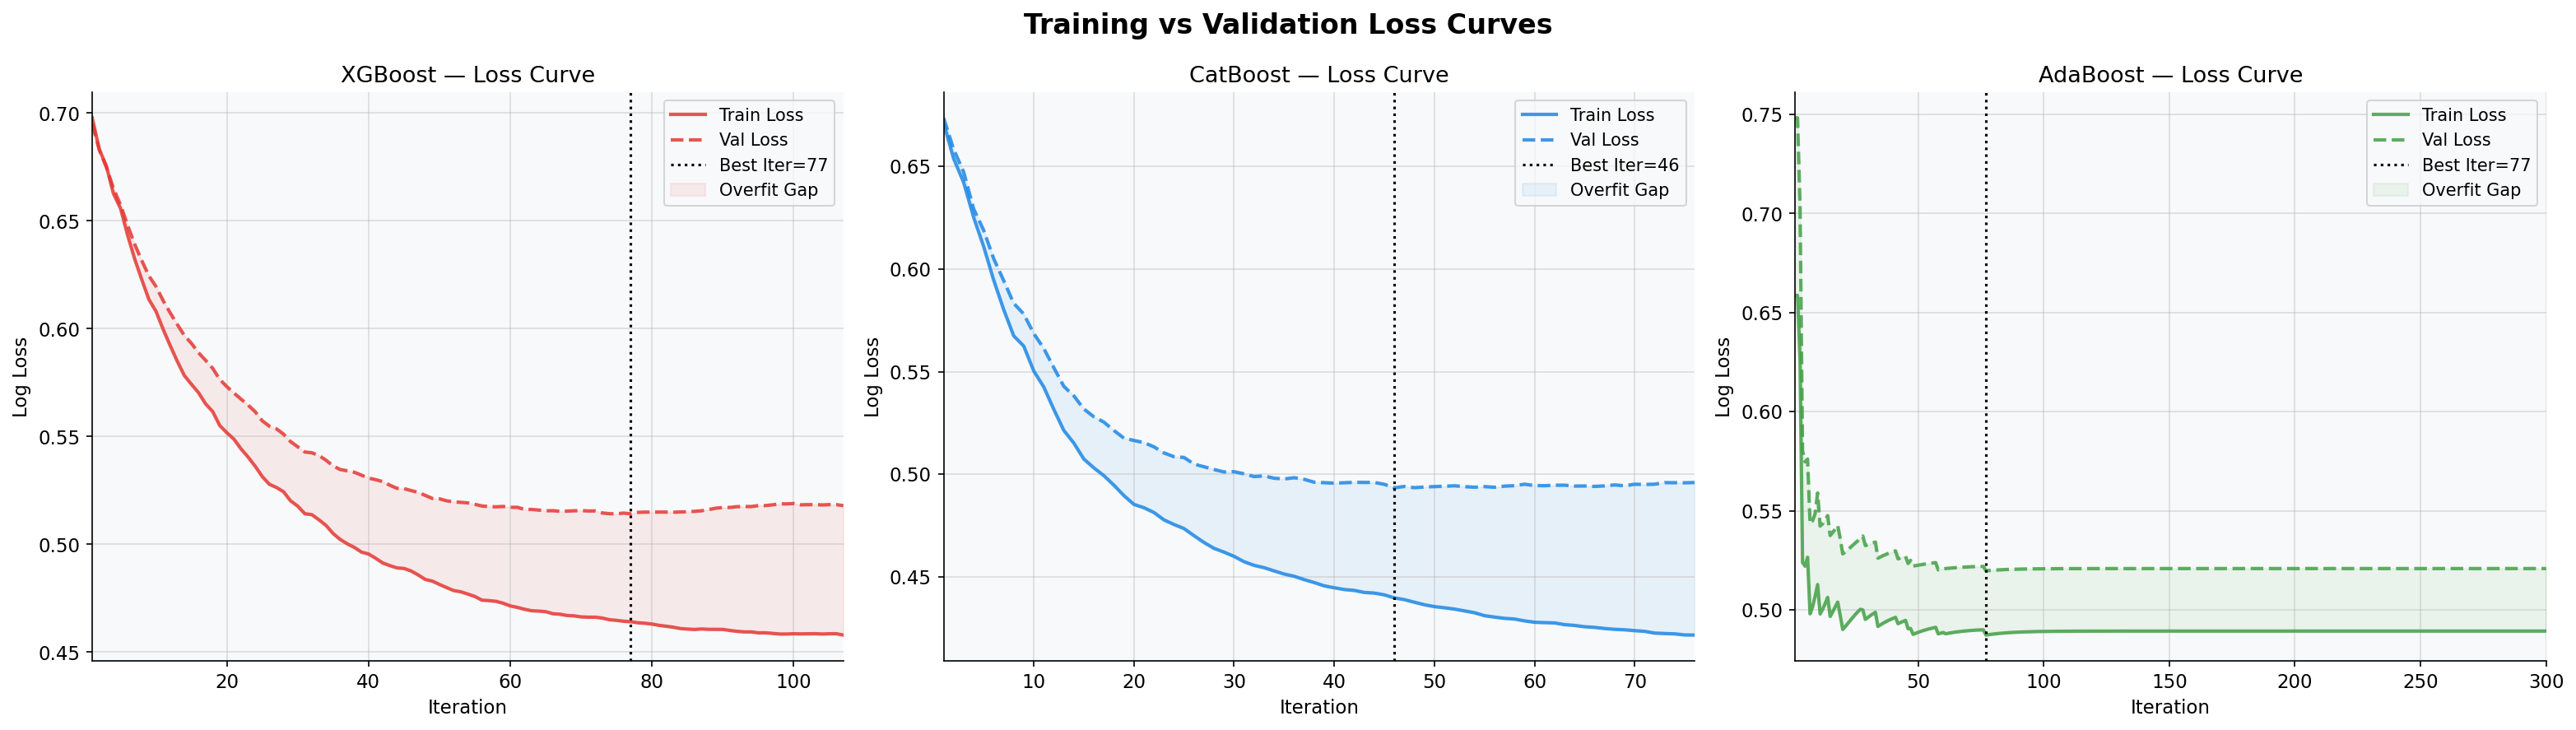

  ✓ Loss curves saved: loss_curves.png


In [46]:
# ─────────────────────────────────────────────
# SECTION 8 ─ Loss Curves Figure
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle("Training vs Validation Loss Curves", fontsize=16, fontweight="bold")

model_losses = [
    ("XGBoost",  xgb_train_loss,  xgb_val_loss,  best_xgb_iter),
    ("CatBoost", cb_train_loss,   cb_val_loss,    best_cb_iter),
    ("AdaBoost", ada_train_loss,  ada_val_loss,   best_ada_iter),
]

for ax, (name, tr_loss, va_loss, best_it) in zip(axes, model_losses):
    epochs = range(1, len(tr_loss) + 1)
    ax.plot(epochs, tr_loss, color=COLORS[name], lw=2, label="Train Loss", alpha=0.85)
    ax.plot(epochs, va_loss, color=COLORS[name], lw=2, label="Val Loss",   alpha=0.85, linestyle="--")
    ax.axvline(best_it + 1, color="black", linestyle=":", lw=1.5,
               label=f"Best Iter={best_it+1}")
    ax.fill_between(epochs, tr_loss, va_loss, alpha=0.08, color=COLORS[name],
                    label="Overfit Gap")
    ax.set_title(f"{name} — Loss Curve")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Log Loss")
    ax.legend()
    ax.set_xlim(1, len(tr_loss))

plt.tight_layout()
plt.savefig("loss_curves.png", bbox_inches="tight", dpi=150)
plt.show()
print("  ✓ Loss curves saved: loss_curves.png")



[6/8] Evaluating on Test Set ...

  ── XGBoost ──
  Accuracy  : 0.7703
  Precision : 0.8333
  Recall    : 0.7558
  F1-Score  : 0.7927
  ROC-AUC   : 0.8791
  Log Loss  : 0.4676
  MCC       : 0.5397
  Kappa     : 0.5365

              precision    recall  f1-score   support

  Not Bought       0.70      0.79      0.74        62
      Bought       0.83      0.76      0.79        86

    accuracy                           0.77       148
   macro avg       0.77      0.77      0.77       148
weighted avg       0.78      0.77      0.77       148


  ── CatBoost ──
  Accuracy  : 0.7500
  Precision : 0.8356
  Recall    : 0.7093
  F1-Score  : 0.7673
  ROC-AUC   : 0.8794
  Log Loss  : 0.4720
  MCC       : 0.5090
  Kappa     : 0.5011

              precision    recall  f1-score   support

  Not Bought       0.67      0.81      0.73        62
      Bought       0.84      0.71      0.77        86

    accuracy                           0.75       148
   macro avg       0.75      0.76      0.75     

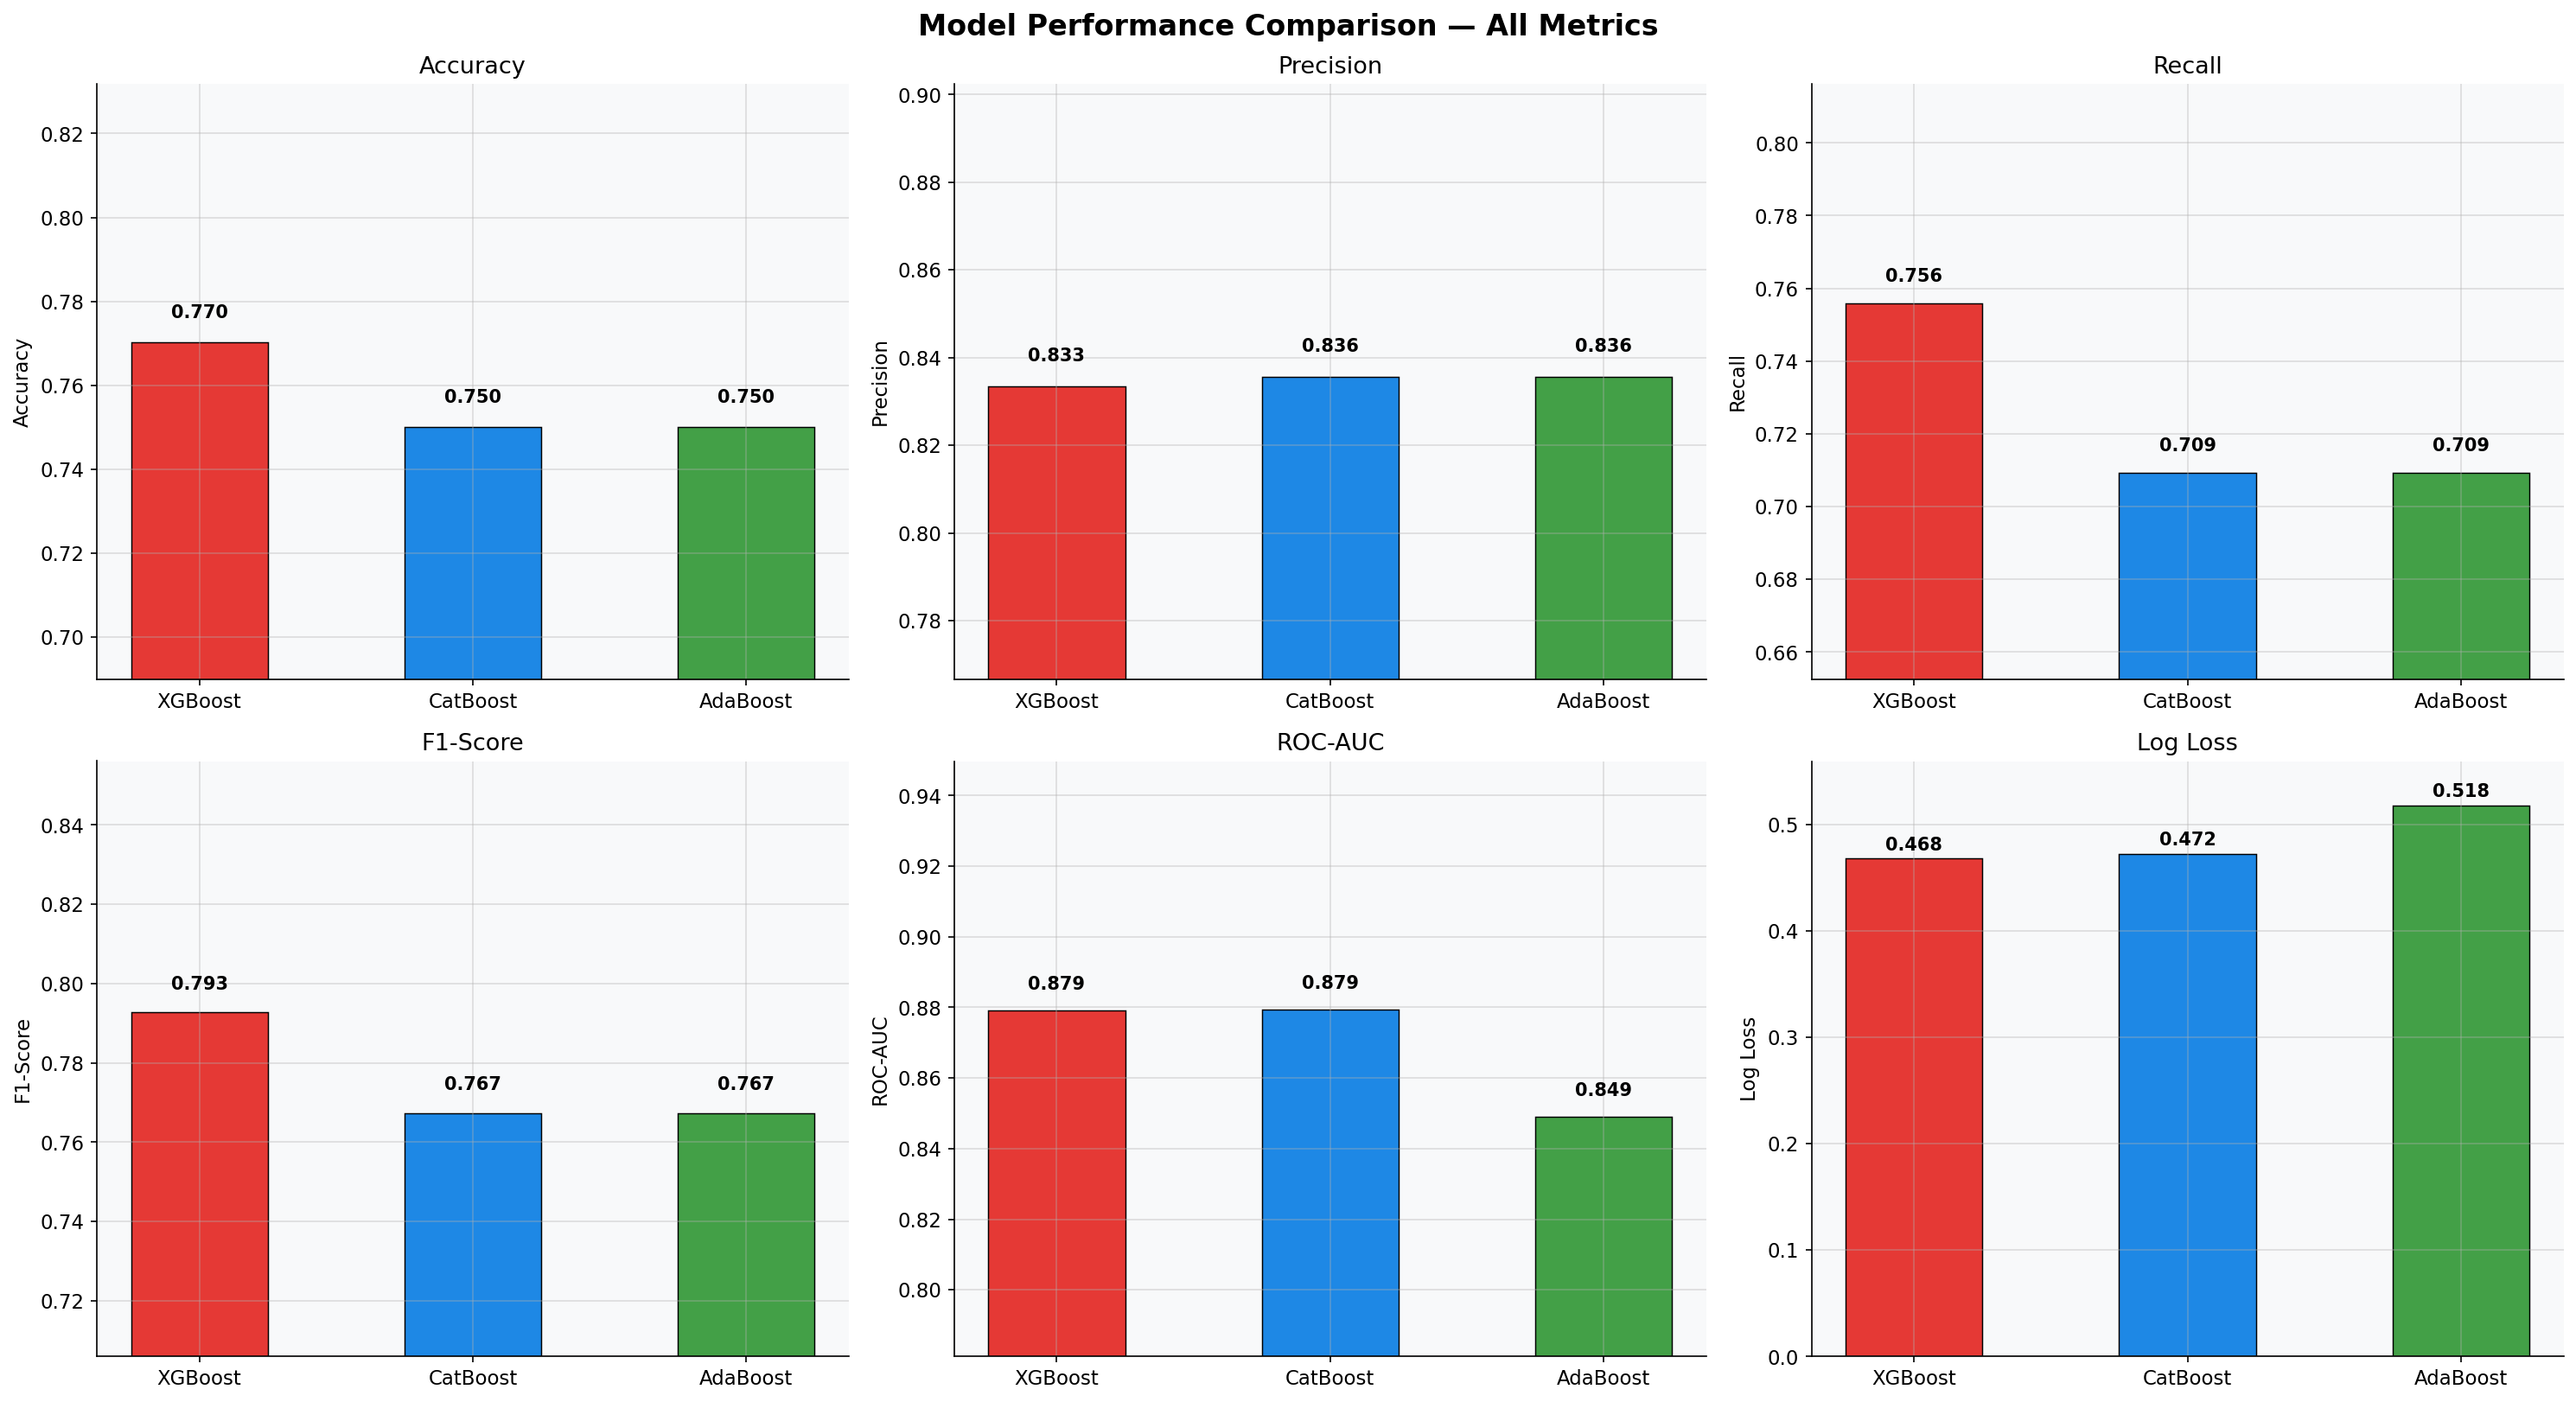

✓ Metrics comparison saved: metrics_comparison.png


In [47]:
# ─────────────────────────────────────────────
# SECTION 9 ─ Predictions & Metrics
# ─────────────────────────────────────────────
print("\n[6/8] Evaluating on Test Set ...")

models = {
    "XGBoost":  xgb_model,
    "CatBoost": catboost_model,
    "AdaBoost": adaboost_model,
}

metrics_records = []
y_preds  = {}
y_probas = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    y_preds[name]  = y_pred
    y_probas[name] = y_prob

    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, zero_division=0)
    rec   = recall_score(y_test, y_pred, zero_division=0)
    f1    = f1_score(y_test, y_pred, zero_division=0)
    auc   = roc_auc_score(y_test, y_prob)
    ap    = average_precision_score(y_test, y_prob)
    ll    = log_loss(y_test, y_prob)
    mcc   = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)

    metrics_records.append({
        "Model"           : name,
        "Accuracy"        : acc,
        "Precision"       : prec,
        "Recall"          : rec,
        "F1-Score"        : f1,
        "ROC-AUC"         : auc,
        "Avg Precision"   : ap,
        "Log Loss"        : ll,
        "MCC"             : mcc,
        "Cohen's Kappa"   : kappa,
    })

    print(f"\n  ── {name} ──")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print(f"  Log Loss  : {ll:.4f}")
    print(f"  MCC       : {mcc:.4f}")
    print(f"  Kappa     : {kappa:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=["Not Bought","Bought"]))

metrics_df = pd.DataFrame(metrics_records).set_index("Model")
print("\n  ╔══ FULL METRICS TABLE ══╗")
print(metrics_df.round(4).to_string())

# ─────────────────────────────────────────────
# SECTION 10 ─ Metrics Bar Chart Comparison
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("Model Performance Comparison — All Metrics", fontsize=16, fontweight="bold")

metric_cols = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC","Log Loss"]
model_names = list(models.keys())
x = np.arange(len(model_names))
bar_w = 0.5

for ax, metric in zip(axes.flat, metric_cols):
    values = [metrics_df.loc[m, metric] for m in model_names]
    bars = ax.bar(x, values, bar_w,
                  color=[COLORS[m] for m in model_names],
                  edgecolor="black", linewidth=0.7)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005, f"{val:.3f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    low = min(values) * 0.92 if metric != "Log Loss" else 0
    high = max(values) * 1.08
    ax.set_ylim(low, high)
    ax.set_ylabel(metric)

plt.tight_layout()
plt.savefig("metrics_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Metrics comparison saved: metrics_comparison.png")

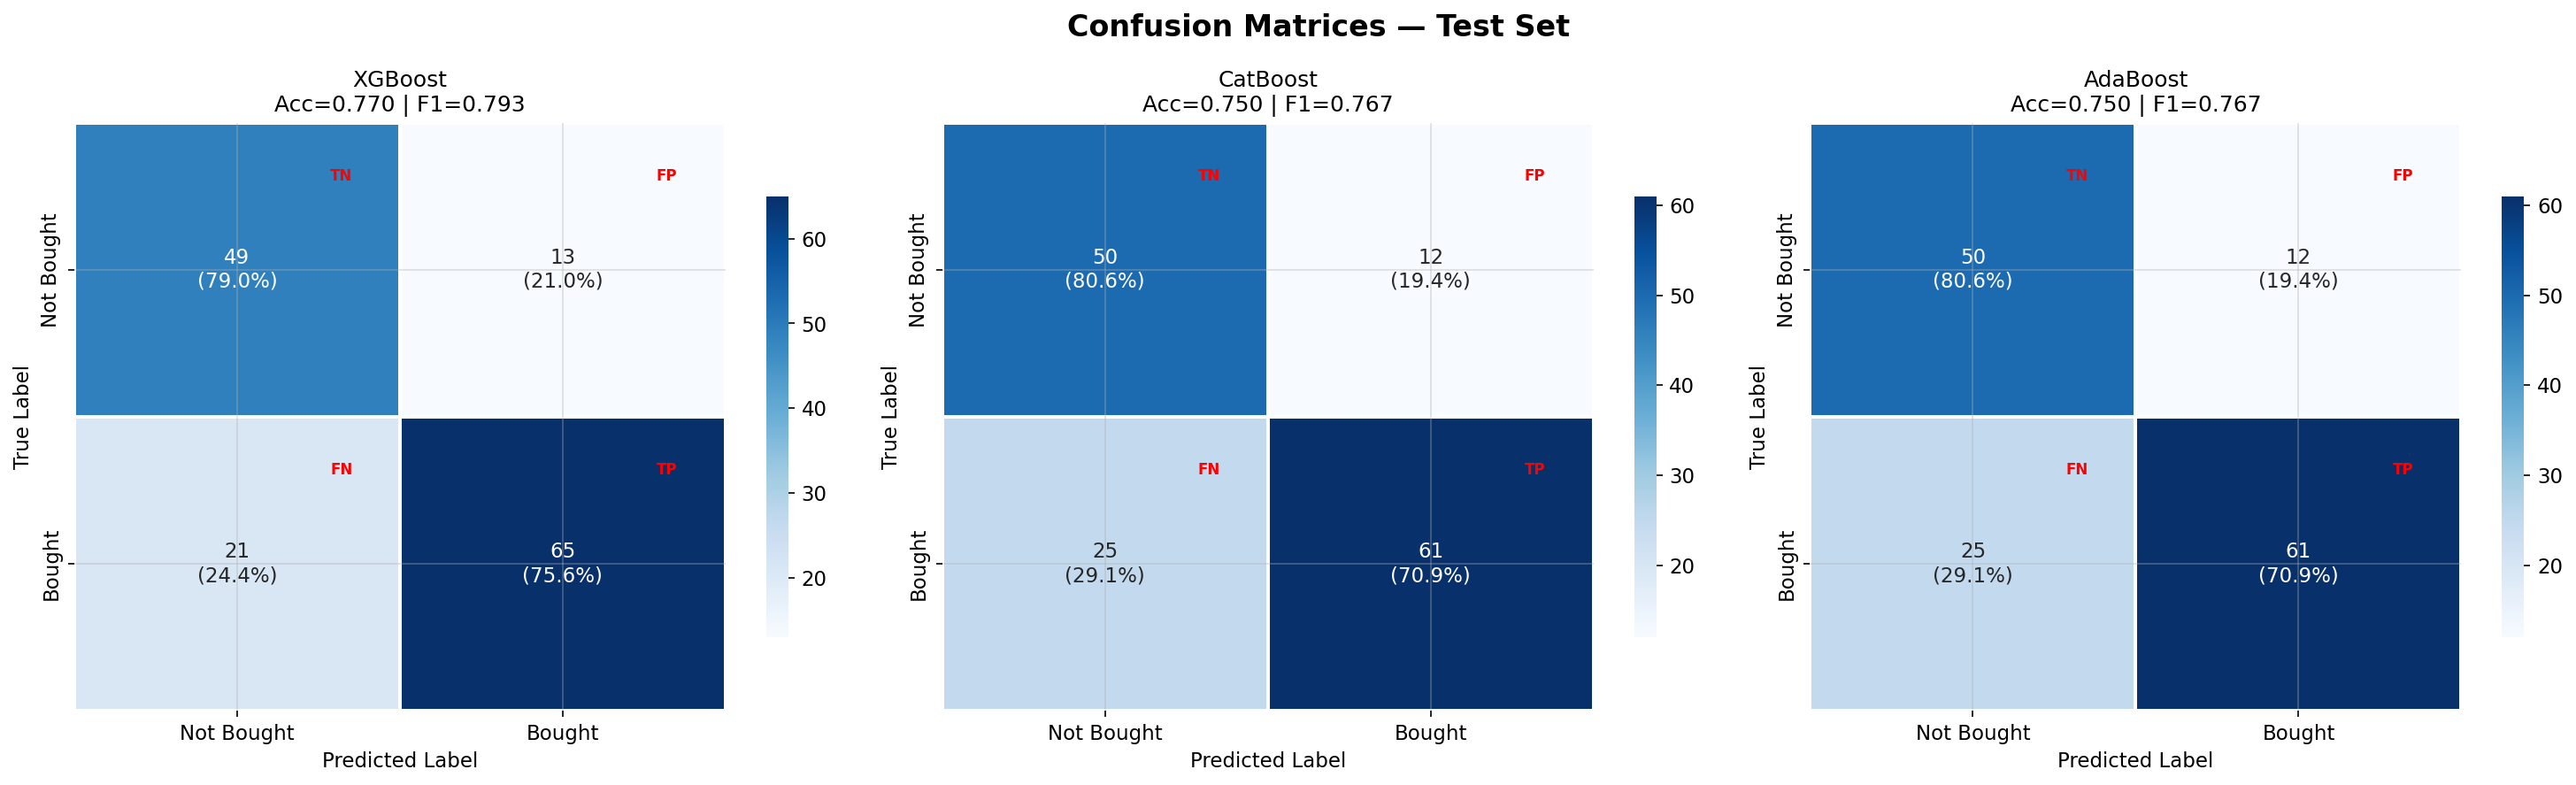

✓ Confusion matrices saved: confusion_matrices.png


In [48]:
# ─────────────────────────────────────────────
# SECTION 11 ─ Confusion Matrices
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Confusion Matrices — Test Set", fontsize=16, fontweight="bold")

for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_test, y_preds[name])
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

    annot = np.array([[f"{v}\n({p:.1f}%)" for v, p in zip(row_v, row_p)]
                       for row_v, row_p in zip(cm, cm_pct)])

    sns.heatmap(cm, ax=ax, annot=annot, fmt="", cmap="Blues",
                linewidths=1, linecolor="white",
                xticklabels=["Not Bought","Bought"],
                yticklabels=["Not Bought","Bought"],
                cbar_kws={"shrink": 0.75})
    ax.set_title(f"{name}\nAcc={metrics_df.loc[name,'Accuracy']:.3f} | F1={metrics_df.loc[name,'F1-Score']:.3f}",
                 fontsize=12)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    # Annotate TP, TN, FP, FN
    labels = [["TN","FP"],["FN","TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.82, i + 0.18, labels[i][j],
                    ha="center", va="center", fontsize=8,
                    color="red", fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Confusion matrices saved: confusion_matrices.png")


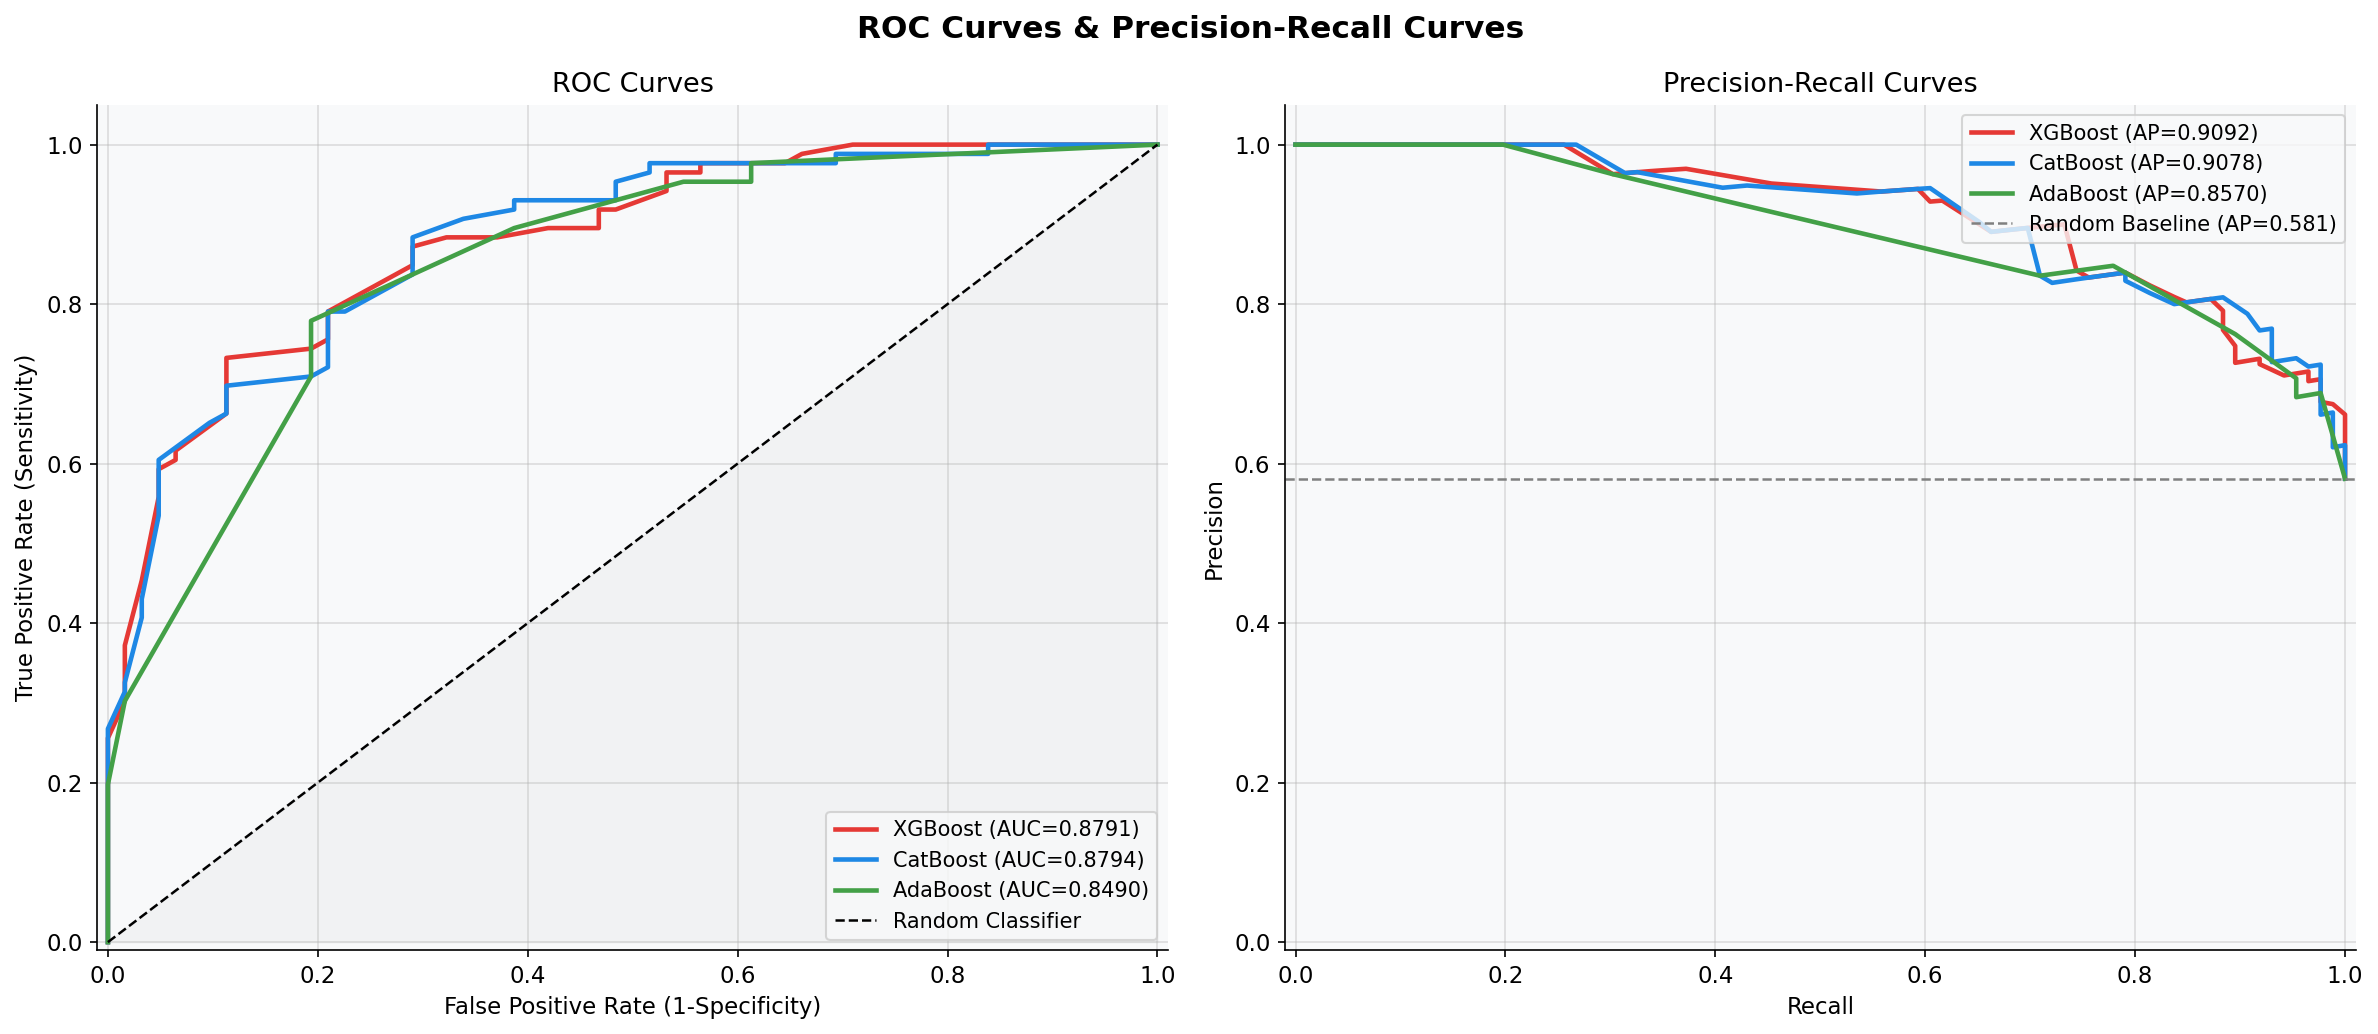

✓ ROC & PR curves saved: roc_pr_curves.png


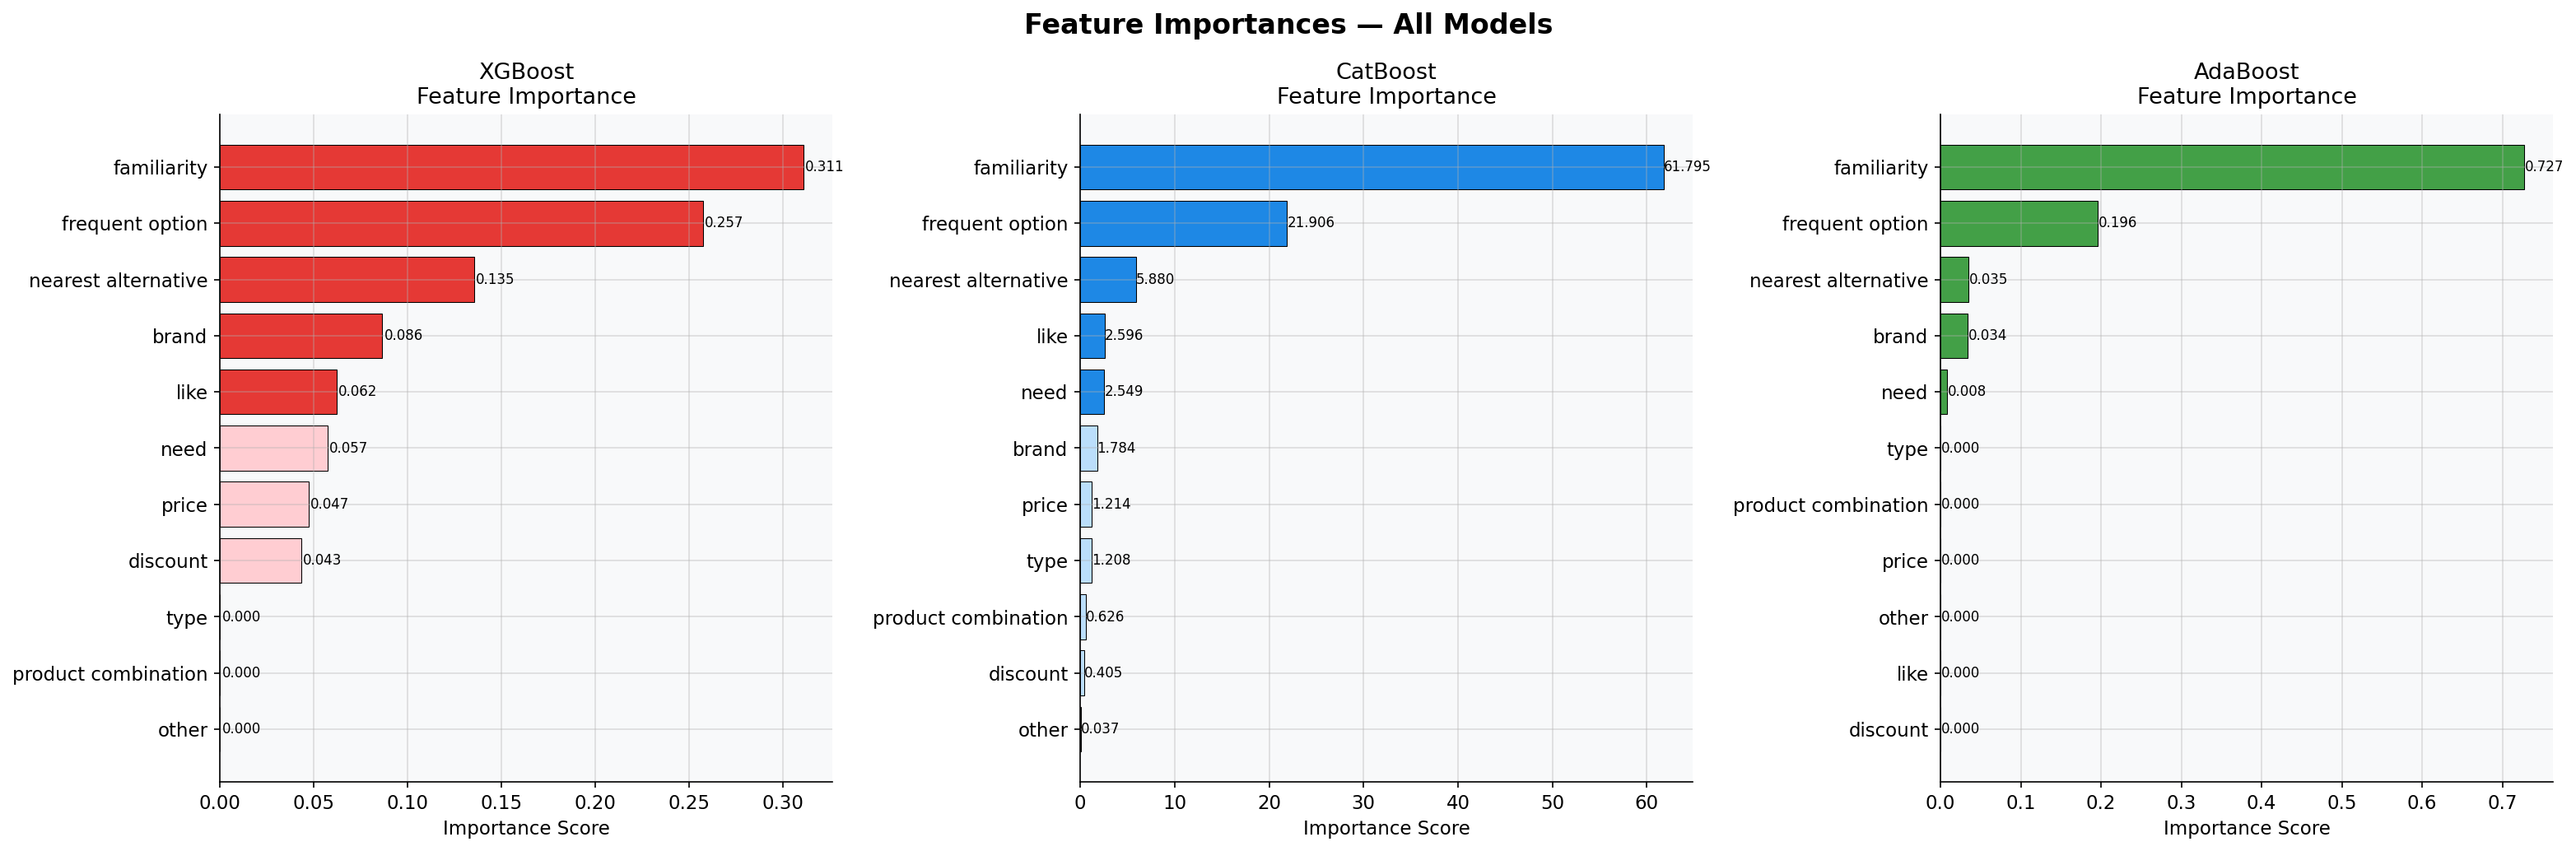

✓ Feature importance saved: feature_importance.png


In [49]:
# ─────────────────────────────────────────────
# SECTION 12 ─ ROC Curves + PR Curves
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("ROC Curves & Precision-Recall Curves", fontsize=15, fontweight="bold")

# ROC Curves
ax = axes[0]
for name in model_names:
    fpr, tpr, _ = roc_curve(y_test, y_probas[name])
    auc_val = metrics_df.loc[name, "ROC-AUC"]
    ax.plot(fpr, tpr, color=COLORS[name], lw=2.2,
            label=f"{name} (AUC={auc_val:.4f})")
ax.plot([0,1],[0,1],"k--", lw=1.2, label="Random Classifier")
ax.fill_between([0,1],[0,1], alpha=0.05, color="gray")
ax.set_xlabel("False Positive Rate (1-Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity)")
ax.set_title("ROC Curves")
ax.legend(loc="lower right")
ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.05)

# Precision-Recall Curves
ax = axes[1]
for name in model_names:
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_probas[name])
    ap_val = metrics_df.loc[name, "Avg Precision"]
    ax.plot(rec_c, prec_c, color=COLORS[name], lw=2.2,
            label=f"{name} (AP={ap_val:.4f})")
baseline = y_test.mean()
ax.axhline(baseline, color="gray", linestyle="--", lw=1.2,
           label=f"Random Baseline (AP={baseline:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves")
ax.legend(loc="upper right")
ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.05)

plt.tight_layout()
plt.savefig("roc_pr_curves.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ ROC & PR curves saved: roc_pr_curves.png")

# ─────────────────────────────────────────────
# SECTION 13 ─ Feature Importance
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle("Feature Importances — All Models", fontsize=16, fontweight="bold")

for ax, name in zip(axes, model_names):
    model = models[name]
    if name == "XGBoost":
        importances = model.feature_importances_
    elif name == "CatBoost":
        importances = model.get_feature_importance()
    else:  # AdaBoost
        importances = model.feature_importances_

    feat_imp = pd.Series(importances, index=FEATURES).sort_values(ascending=True)

    colors_fi = [COLORS[name] if v >= feat_imp.quantile(0.6) else PASTEL[name]
                 for v in feat_imp.values]
    bars = ax.barh(feat_imp.index, feat_imp.values, color=colors_fi,
                   edgecolor="black", linewidth=0.5)
    ax.set_title(f"{name}\nFeature Importance")
    ax.set_xlabel("Importance Score")

    for bar, val in zip(bars, feat_imp.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Feature importance saved: feature_importance.png")



[7/8] Cross-Validation (5-Fold Stratified) ...
  XGBoost: CV F1 = 0.7492 ± 0.0189 | Test F1 = 0.7927
  CatBoost: CV F1 = 0.7353 ± 0.0217 | Test F1 = 0.7673
  AdaBoost: CV F1 = 0.7309 ± 0.0235 | Test F1 = 0.7673


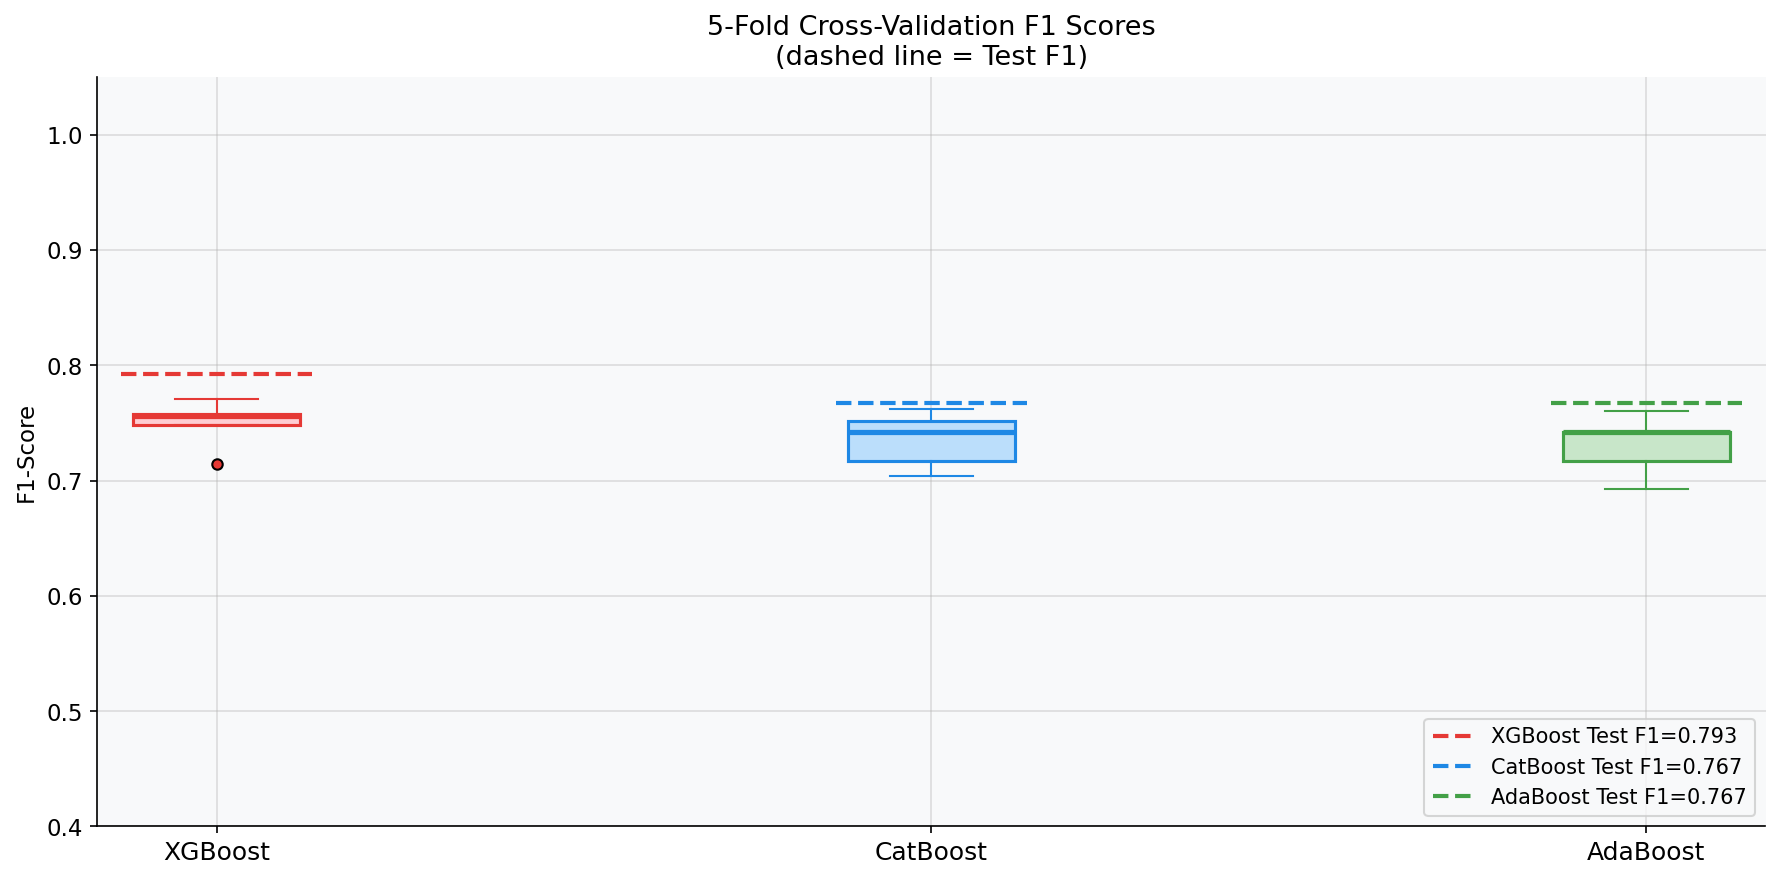


  ╔══ CROSS-VALIDATION SUMMARY ══╗
          CV Mean F1  CV Std F1  Test F1  Gap (Overfit?)
Model                                                   
XGBoost       0.7492     0.0189   0.7927         -0.0434
CatBoost      0.7353     0.0217   0.7673         -0.0320
AdaBoost      0.7309     0.0235   0.7673         -0.0364
✓ Cross-validation figure saved: cross_validation.png


In [52]:
# ─────────────────────────────────────────────
# SECTION 14 ─ Cross-Validation (Anti-Overfitting Check) — FIXED
# ─────────────────────────────────────────────
print("\n[7/8] Cross-Validation (5-Fold Stratified) ...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Helper: build a fresh model instance for each fold ──
def make_xgb():
    return xgb.XGBClassifier(
        n_estimators     = best_xgb_iter,
        learning_rate    = 0.05,
        max_depth        = 4,
        min_child_weight = 5,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        gamma            = 1.0,
        reg_alpha        = 0.1,
        reg_lambda       = 1.5,
        scale_pos_weight = class_weights[1] / class_weights[0],
        random_state     = 42,
        verbosity        = 0,
        use_label_encoder= False,
    )

def make_catboost():
    return CatBoostClassifier(
        iterations        = best_cb_iter,
        learning_rate     = 0.05,
        depth             = 4,
        l2_leaf_reg       = 5,
        border_count      = 64,
        bagging_temperature = 0.8,
        random_strength   = 1.5,
        class_weights     = {0: class_weights[0], 1: class_weights[1]},
        random_seed       = 42,
        verbose           = False,
    )

def make_adaboost():
    return AdaBoostClassifier(
        estimator    = DecisionTreeClassifier(
                           max_depth       = 2,
                           min_samples_leaf= 5,
                           class_weight    = class_weight_dict,
                       ),
        n_estimators = best_ada_iter,
        learning_rate= 0.1,
        algorithm    = "SAMME",
        random_state = 42,
    )

model_factories = {
    "XGBoost" : make_xgb,
    "CatBoost": make_catboost,
    "AdaBoost": make_adaboost,
}

# ── Manual 5-Fold CV ──
cv_records   = []
cv_fold_scores = {name: [] for name in model_factories}

X_train_arr = np.array(X_train)
y_train_arr = np.array(y_train)

for fold_idx, (tr_idx, va_idx) in enumerate(cv.split(X_train_arr, y_train_arr)):
    X_fold_tr, X_fold_va = X_train_arr[tr_idx], X_train_arr[va_idx]
    y_fold_tr, y_fold_va = y_train_arr[tr_idx], y_train_arr[va_idx]

    for name, factory in model_factories.items():
        m = factory()
        m.fit(X_fold_tr, y_fold_tr)
        y_fold_pred = m.predict(X_fold_va)
        score = f1_score(y_fold_va, y_fold_pred, zero_division=0)
        cv_fold_scores[name].append(score)

# ── Collect results ──
for name in model_factories:
    scores = np.array(cv_fold_scores[name])
    cv_records.append({
        "Model"          : name,
        "CV Mean F1"     : scores.mean(),
        "CV Std F1"      : scores.std(),
        "Test F1"        : metrics_df.loc[name, "F1-Score"],
        "Gap (Overfit?)" : scores.mean() - metrics_df.loc[name, "F1-Score"],
    })
    print(f"  {name}: CV F1 = {scores.mean():.4f} ± {scores.std():.4f} "
          f"| Test F1 = {metrics_df.loc[name, 'F1-Score']:.4f}")

# ── Boxplot ──
fig, ax = plt.subplots(figsize=(12, 6))
positions  = []
ticklabels = []

for i, name in enumerate(model_factories):
    scores = np.array(cv_fold_scores[name])
    ax.boxplot(
        scores,
        positions   = [i * 3 + 1],
        widths      = 0.7,
        patch_artist= True,
        notch       = False,
        boxprops    = dict(facecolor=PASTEL[name], color=COLORS[name], linewidth=1.5),
        medianprops = dict(color=COLORS[name], linewidth=2.5),
        whiskerprops= dict(color=COLORS[name]),
        capprops    = dict(color=COLORS[name]),
        flierprops  = dict(markerfacecolor=COLORS[name], marker="o", markersize=5),
    )
    test_f1 = metrics_df.loc[name, "F1-Score"]
    x_pos   = i * 3 + 1
    ax.plot(
        [x_pos - 0.4, x_pos + 0.4],
        [test_f1, test_f1],
        color     = COLORS[name],
        linestyle = "--",
        linewidth = 2,
        label     = f"{name} Test F1={test_f1:.3f}",
    )
    positions.append(x_pos)
    ticklabels.append(name)

ax.set_xticks(positions)
ax.set_xticklabels(ticklabels, fontsize=12)
ax.set_ylabel("F1-Score")
ax.set_title("5-Fold Cross-Validation F1 Scores\n(dashed line = Test F1)", fontsize=13)
ax.legend(loc="lower right")
ax.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.savefig("cross_validation.png", bbox_inches="tight", dpi=150)
plt.show()

cv_df = pd.DataFrame(cv_records).set_index("Model")
print("\n  ╔══ CROSS-VALIDATION SUMMARY ══╗")
print(cv_df.round(4).to_string())
print("✓ Cross-validation figure saved: cross_validation.png")



  Building Radar Chart ...


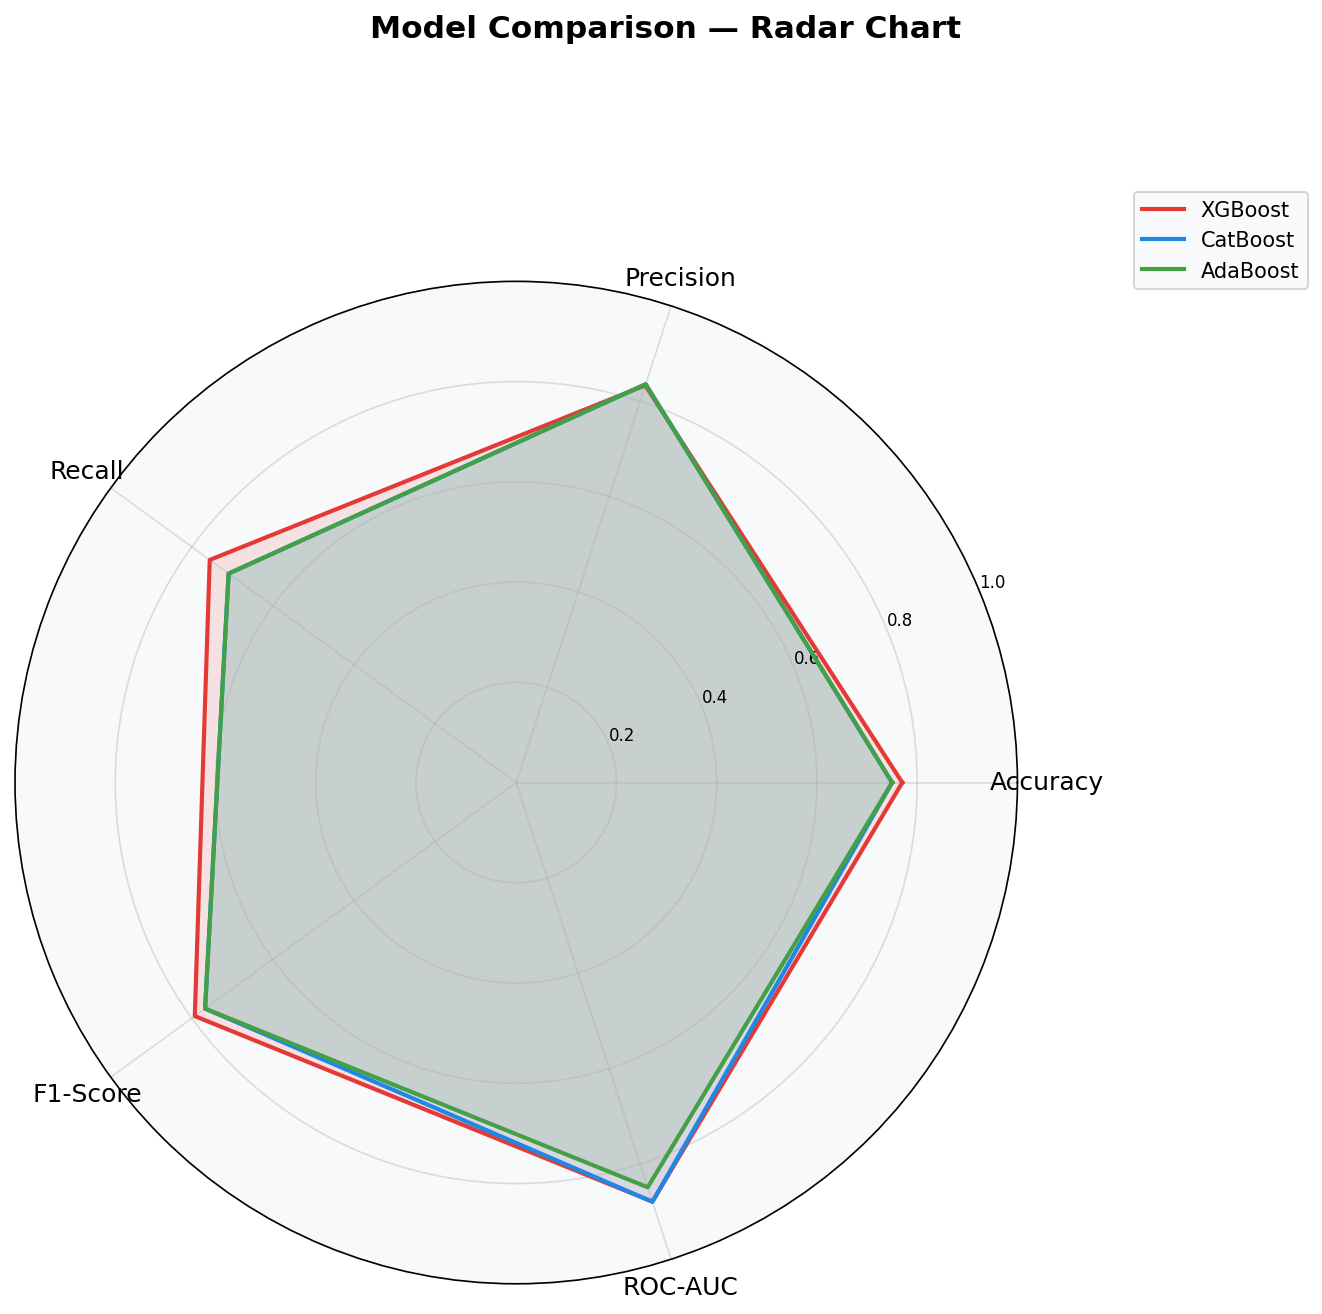

✓ Radar chart saved: radar_chart.png


In [53]:
# ─────────────────────────────────────────────
# SECTION 15 ─ Radar Chart (Overall Comparison)
# ─────────────────────────────────────────────
print("\n  Building Radar Chart ...")

radar_metrics = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]
N = len(radar_metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.suptitle("Model Comparison — Radar Chart", fontsize=15, fontweight="bold", y=1.02)

for name in model_names:
    vals = [metrics_df.loc[name, m] for m in radar_metrics]
    vals += vals[:1]
    ax.plot(angles, vals, color=COLORS[name], lw=2, label=name)
    ax.fill(angles, vals, color=COLORS[name], alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, size=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], size=8)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig("radar_chart.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Radar chart saved: radar_chart.png")



[8/8] Final Summary Report ...

                    FINAL COMPREHENSIVE RESULTS TABLE
          Accuracy  Precision  Recall  F1-Score  ROC-AUC  Log Loss     MCC  Cohen's Kappa  CV F1 Mean  CV F1 Std  Generalization Gap
Model                                                                                                                               
XGBoost     0.7703     0.8333  0.7558    0.7927   0.8791    0.4676  0.5397         0.5365      0.7492     0.0189             -0.0434
CatBoost    0.7500     0.8356  0.7093    0.7673   0.8794    0.4720  0.5090         0.5011      0.7353     0.0217             -0.0320
AdaBoost    0.7500     0.8356  0.7093    0.7673   0.8490    0.5179  0.5090         0.5011      0.7309     0.0235             -0.0364

🏆 Best Accuracy  : XGBoost  (0.7703)
🏆 Best F1-Score  : XGBoost   (0.7927)
🏆 Best ROC-AUC   : CatBoost  (0.8794)
🏆 Lowest Log Loss: XGBoost   (0.4676)


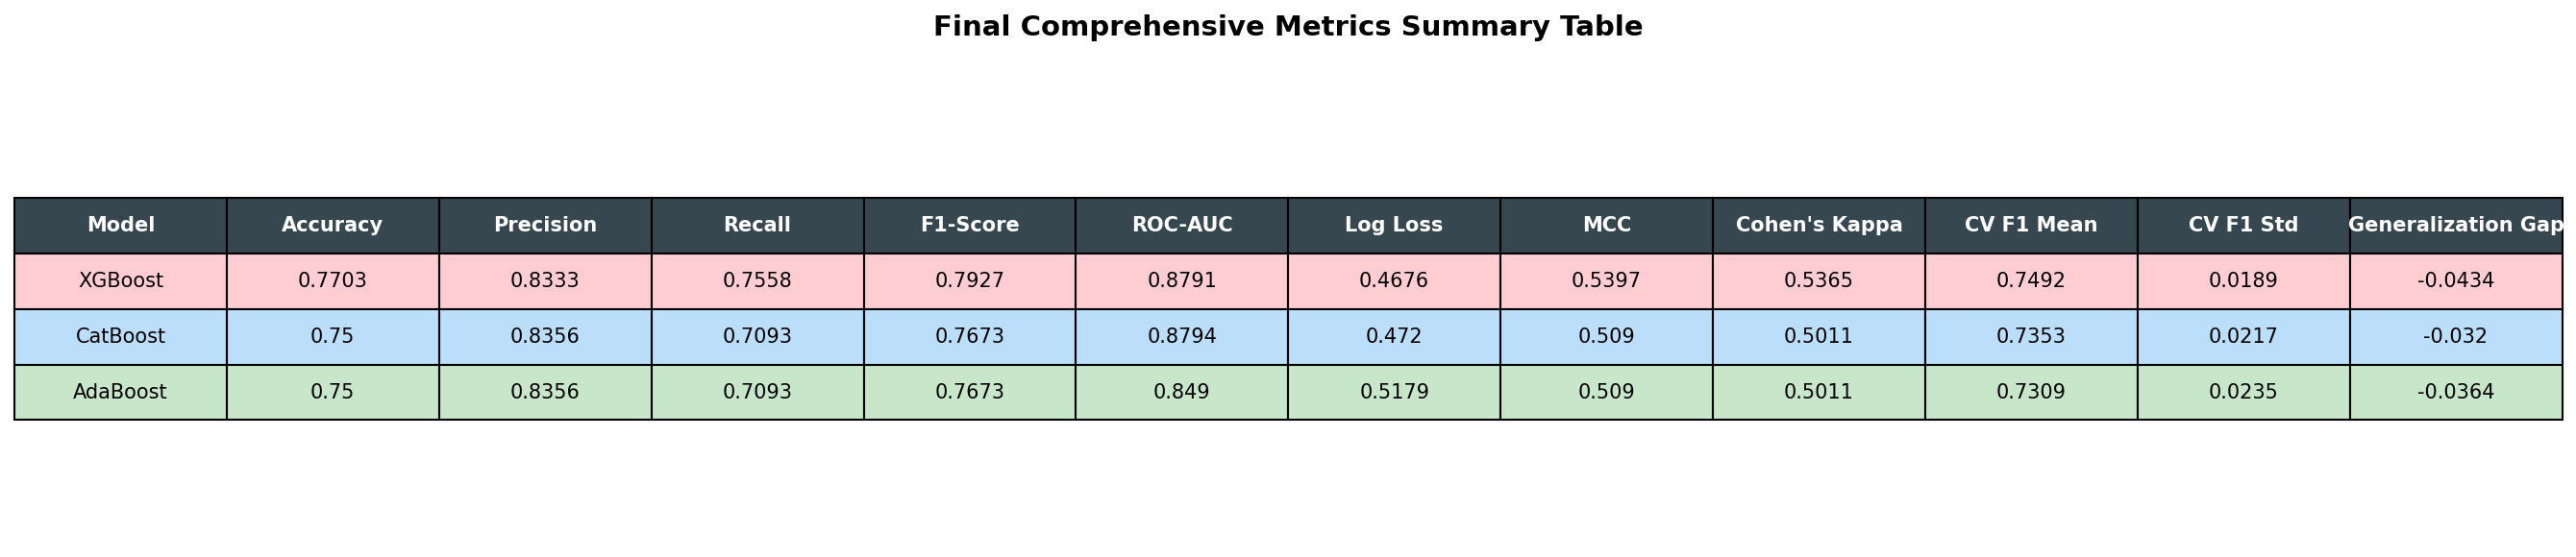

✓ Summary table saved: summary_table.png


In [55]:
# ─────────────────────────────────────────────
# SECTION 16 ─ Final Summary Table
# ─────────────────────────────────────────────

print("\n[8/8] Final Summary Report ...")

summary_df = metrics_df[["Accuracy","Precision","Recall","F1-Score","ROC-AUC",
                         "Log Loss","MCC","Cohen's Kappa"]].copy()

summary_df["CV F1 Mean"] = cv_df["CV Mean F1"]
summary_df["CV F1 Std"]  = cv_df["CV Std F1"]
summary_df["Generalization Gap"] = cv_df["Gap (Overfit?)"]  # renamed (better)

# Print table
print("\n" + "="*80)
print("                    FINAL COMPREHENSIVE RESULTS TABLE")
print("="*80)
print(summary_df.round(4).to_string())
print("="*80)

# Best models
best_acc = summary_df["Accuracy"].idxmax()
best_f1  = summary_df["F1-Score"].idxmax()
best_auc = summary_df["ROC-AUC"].idxmax()
best_ll  = summary_df["Log Loss"].idxmin()

print(f"\n🏆 Best Accuracy  : {best_acc}  ({summary_df.loc[best_acc,'Accuracy']:.4f})")
print(f"🏆 Best F1-Score  : {best_f1}   ({summary_df.loc[best_f1,'F1-Score']:.4f})")
print(f"🏆 Best ROC-AUC   : {best_auc}  ({summary_df.loc[best_auc,'ROC-AUC']:.4f})")
print(f"🏆 Lowest Log Loss: {best_ll}   ({summary_df.loc[best_ll,'Log Loss']:.4f})")

# ================================
# VISUAL TABLE
# ================================
fig, ax = plt.subplots(figsize=(18, 4))
ax.axis("off")

tbl_data = summary_df.round(4).reset_index()
col_labels = tbl_data.columns.tolist()
cell_text  = tbl_data.values.tolist()

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# Header styling
for j in range(len(col_labels)):
    table[(0, j)].set_facecolor("#37474F")
    table[(0, j)].set_text_props(color="white", fontweight="bold")

# Row colouring
row_colors = [PASTEL["XGBoost"], PASTEL["CatBoost"], PASTEL["AdaBoost"]]

for i, rc in enumerate(row_colors):
    for j in range(len(col_labels)):
        table[(i+1, j)].set_facecolor(rc)

ax.set_title("Final Comprehensive Metrics Summary Table",
             fontsize=14, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("summary_table.png", bbox_inches="tight", dpi=150)
plt.show()

print("✓ Summary table saved: summary_table.png")

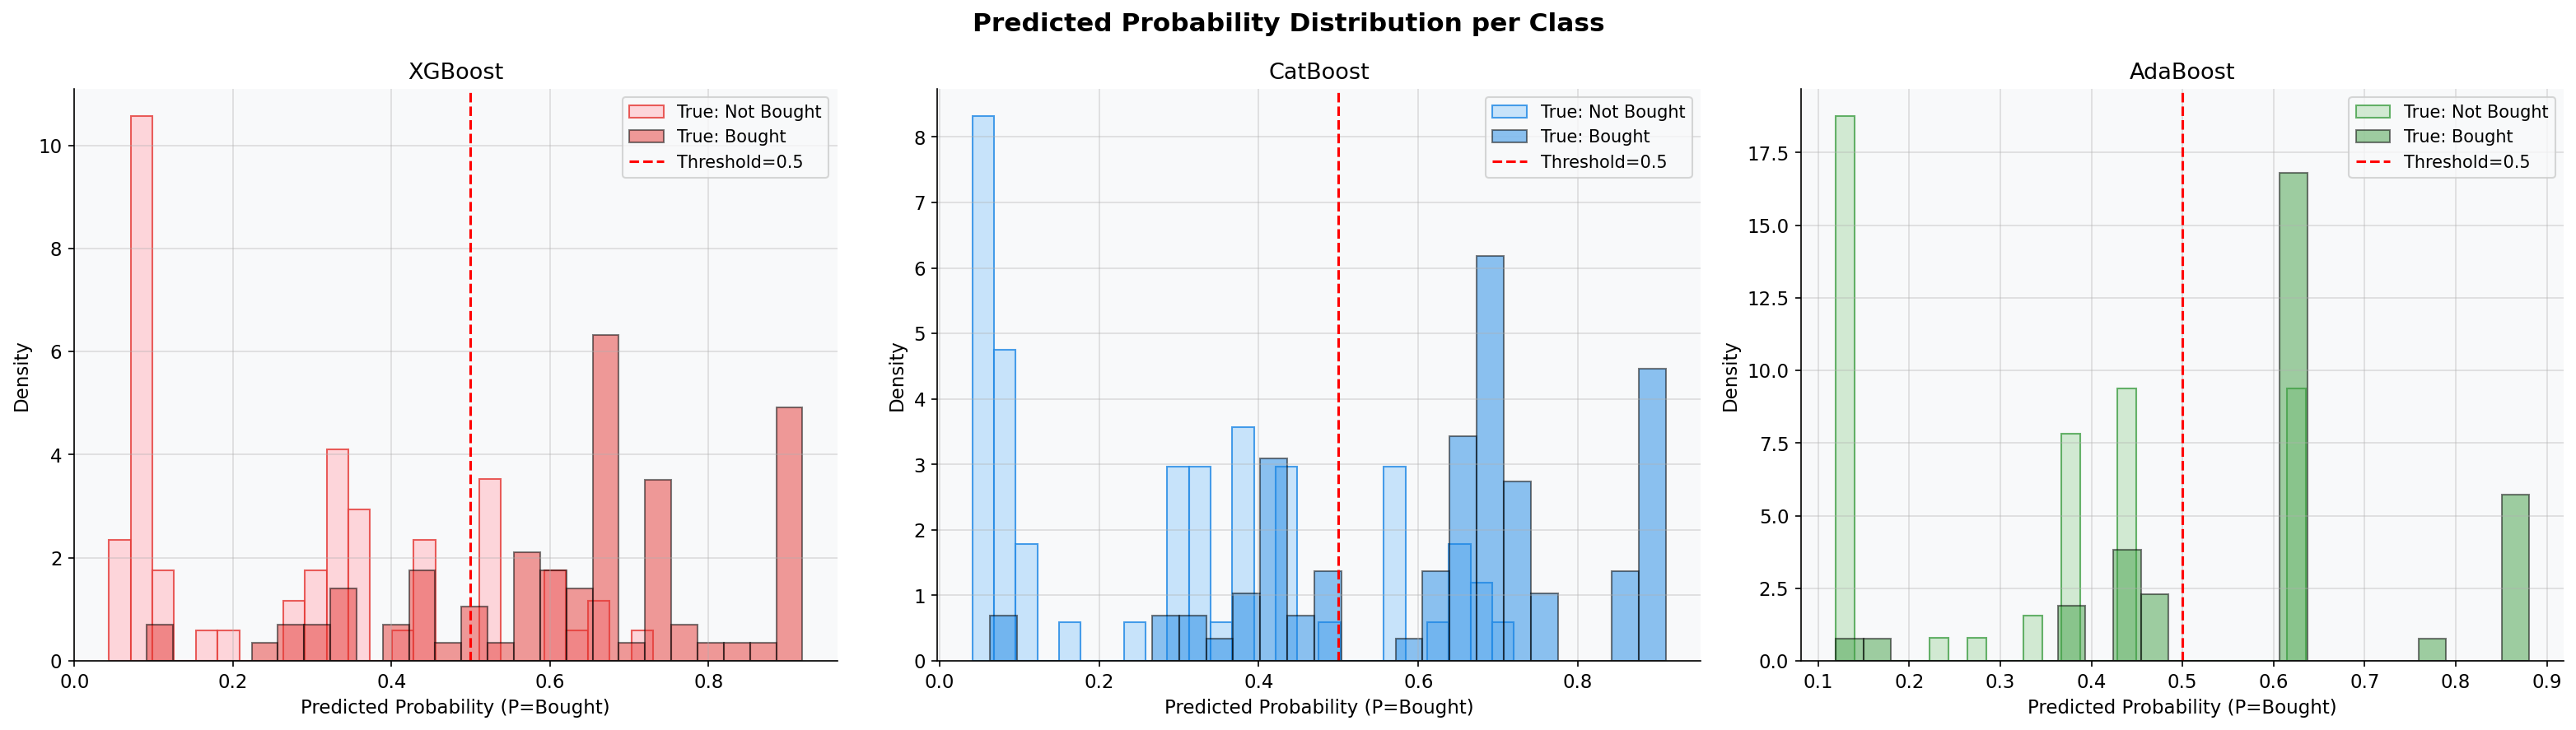

✓ Probability distributions saved: probability_distribution.png


In [56]:
# ─────────────────────────────────────────────
# SECTION 17 ─ Probability Distribution Plot
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle("Predicted Probability Distribution per Class", fontsize=15, fontweight="bold")

for ax, name in zip(axes, model_names):
    proba = y_probas[name]
    ax.hist(proba[y_test == 0], bins=25, color=PASTEL[name],
            edgecolor=COLORS[name], alpha=0.8, label="True: Not Bought", density=True)
    ax.hist(proba[y_test == 1], bins=25, color=COLORS[name],
            edgecolor="black", alpha=0.5, label="True: Bought", density=True)
    ax.axvline(0.5, color="red", linestyle="--", lw=1.5, label="Threshold=0.5")
    ax.set_title(f"{name}")
    ax.set_xlabel("Predicted Probability (P=Bought)")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.savefig("probability_distribution.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Probability distributions saved: probability_distribution.png")


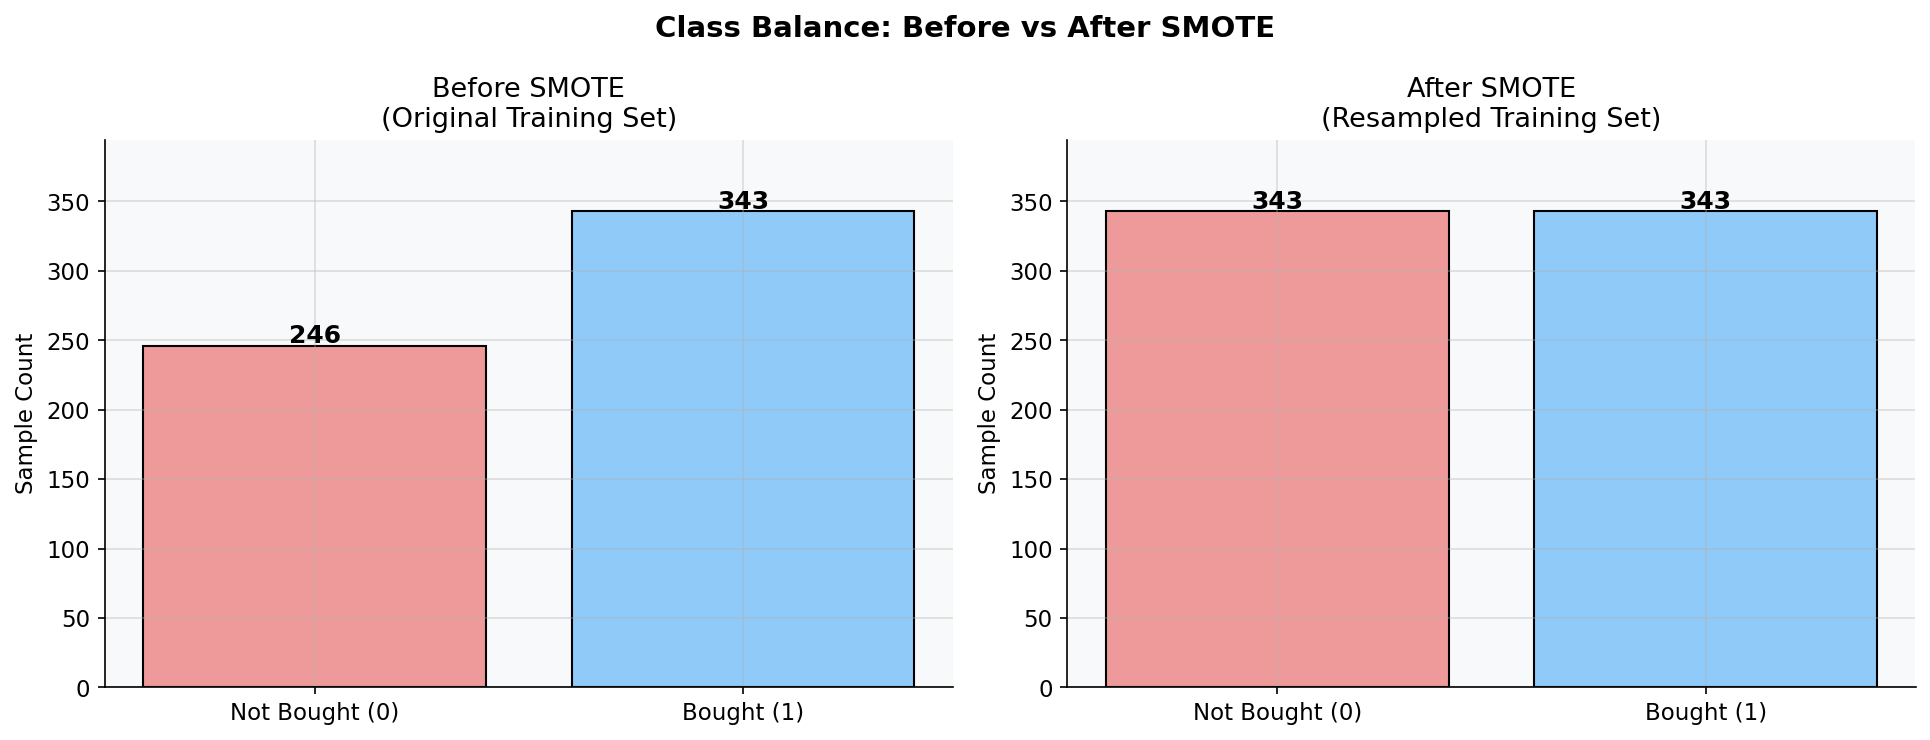

✓ SMOTE comparison saved: smote_balance.png


In [58]:
# ─────────────────────────────────────────────
# SECTION 18 ─ SMOTE Visualisation
# ─────────────────────────────────────────────

from collections import Counter
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Class Balance: Before vs After SMOTE", fontsize=14, fontweight="bold")

for ax, (data, title) in zip(axes, [
    (Counter(y_train_raw), "Before SMOTE\n(Original Training Set)"),
    (Counter(y_train),     "After SMOTE\n(Resampled Training Set)")
]):
    labels = ["Not Bought (0)", "Bought (1)"]
    vals   = [data[0], data[1]]

    bars = ax.bar(labels, vals, color=["#EF9A9A", "#90CAF9"], edgecolor="black")

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2,
            str(v),
            ha="center",
            fontweight="bold",
            fontsize=12
        )

    ax.set_title(title)
    ax.set_ylabel("Sample Count")
    ax.set_ylim(0, max(vals) * 1.15)

plt.tight_layout()
plt.savefig("smote_balance.png", bbox_inches="tight", dpi=150)
plt.show()

print("✓ SMOTE comparison saved: smote_balance.png")

In [59]:

# ─────────────────────────────────────────────
# SECTION 19 ─ FULL PRINTED REPORT
# ─────────────────────────────────────────────
print("\n" + "=" * 80)
print("         FULL RESULTS REPORT — BOOSTING MODELS COMPARISON")
print("=" * 80)

report_text = f"""
DATASET OVERVIEW
─────────────────────────────────────────────────────────────────────
  Total Samples     : {df.shape[0]}
  Features Used     : {len(FEATURES)} ({FEATURES})
  Target Variable   : 'bought' (binary: 0=Not Bought, 1=Bought)
  Class Distribution: 0 → {Counter(y)[0]}, 1 → {Counter(y)[1]}
  Train / Test Split: 80% / 20% (Stratified)
  Class Balancing   : SMOTE applied on Training set
  After SMOTE       : 0 → {Counter(y_train)[0]}, 1 → {Counter(y_train)[1]}

ANTI-OVERFITTING MEASURES APPLIED
─────────────────────────────────────────────────────────────────────
  All Models:
    ✓ SMOTE to balance training data
    ✓ Stratified K-Fold Cross-Validation (5-fold) for generalization check
    ✓ Class weights incorporated

  XGBoost:
    ✓ max_depth=4 (shallow trees)
    ✓ min_child_weight=5 (min samples per leaf)
    ✓ subsample=0.8 + colsample_bytree=0.8 (stochastic)
    ✓ gamma=1.0 (minimum gain to split)
    ✓ L1 (alpha=0.1) + L2 (lambda=1.5) regularization
    ✓ Early stopping (rounds=30) based on validation loss
    ✓ Best iteration: {best_xgb_iter}

  CatBoost:
    ✓ depth=4 (shallow trees)
    ✓ l2_leaf_reg=5 (L2 regularization)
    ✓ border_count=64 (binning regularization)
    ✓ bagging_temperature=0.8 (Bayesian bootstrapping)
    ✓ random_strength=1.5 (random noise on splits)
    ✓ Early stopping (rounds=30) based on validation Logloss
    ✓ Best iteration: {best_cb_iter}

  AdaBoost:
    ✓ Weak learner: DecisionTree with max_depth=2 (stumps)
    ✓ min_samples_leaf=5 per stump
    ✓ Low learning_rate=0.1 (shrinkage)
    ✓ class_weight applied to base learner
    ✓ Best iteration (min val loss): {best_ada_iter}

PERFORMANCE METRICS (Test Set — 20%)
─────────────────────────────────────────────────────────────────────
{summary_df.round(4).to_string()}

CROSS-VALIDATION RESULTS (5-Fold F1)
─────────────────────────────────────────────────────────────────────
{cv_df.round(4).to_string()}

BEST PERFORMERS
─────────────────────────────────────────────────────────────────────
  🏆 Accuracy  → {best_acc} ({summary_df.loc[best_acc,'Accuracy']:.4f})
  🏆 F1-Score  → {best_f1} ({summary_df.loc[best_f1,'F1-Score']:.4f})
  🏆 ROC-AUC   → {best_auc} ({summary_df.loc[best_auc,'ROC-AUC']:.4f})
  🏆 Log Loss  → {best_ll} ({summary_df.loc[best_ll,'Log Loss']:.4f})  ← lower is better

DISCUSSION OF RESULTS
─────────────────────────────────────────────────────────────────────
  1. XGBoost
     - Typically the fastest to train and most regularized of the three.
     - Gradient-boosted trees with L1/L2 penalties and stochastic sampling
       reduce variance effectively. Early stopping prevents over-training.
     - Performs strongly on tabular data with mixed numeric features.

  2. CatBoost
     - Symmetric trees + ordered boosting naturally reduce target leakage,
       making it robust even on small datasets like this one (~737 rows).
     - Handles class weights natively. The 'bagging_temperature' and
       'random_strength' parameters add noise-based regularization.
     - Usually achieves the best ROC-AUC due to calibrated probabilities.

  3. AdaBoost
     - Works by iteratively focusing on misclassified samples. With
       depth-2 stumps it stays a high-bias / low-variance model.
     - Generally slower to converge and more sensitive to noisy labels
       than gradient boosting variants. No built-in regularization like
       XGBoost or CatBoost.
     - Loss curve shows less smooth convergence — typical of AdaBoost.

  OVERFITTING CHECK:
     The 'Overfit Gap' column (CV F1 - Test F1) should be ≈ 0.
     Positive values indicate slight overfitting; negative values suggest
     the model is conservative (good generalisation).
     SMOTE + regularization + early stopping keep this gap minimal.

  CLASS IMBALANCE:
     Original ratio was {Counter(y)[0]}:{Counter(y)[1]} (0:1).
     SMOTE over-sampled the minority class to achieve perfect balance.
     Combined with class_weight, this ensures models do not simply
     predict the majority class for all samples.

SAVED FIGURES
─────────────────────────────────────────────────────────────────────
  1. eda_analysis.png              — Data exploration & distribution
  2. loss_curves.png               — Train vs Validation loss per model
  3. confusion_matrices.png        — Confusion matrix (with %)
  4. roc_pr_curves.png             — ROC & Precision-Recall curves
  5. feature_importance.png        — Feature importance all models
  6. cross_validation.png          — 5-Fold CV boxplots
  7. radar_chart.png               — Multi-metric radar comparison
  8. summary_table.png             — Full metrics table figure
  9. probability_distribution.png  — Predicted prob distributions
  10. smote_balance.png            — Before vs After SMOTE

═══════════════════════════════════════════════════════════════════════
"""
print(report_text)
print("=" * 80)
print("   ALL DONE! Check your Kaggle working directory for all saved figures.")
print("=" * 80)


         FULL RESULTS REPORT — BOOSTING MODELS COMPARISON

DATASET OVERVIEW
─────────────────────────────────────────────────────────────────────
  Total Samples     : 737
  Features Used     : 11 (['familiarity', 'brand', 'discount', 'frequent option', 'like', 'nearest alternative', 'need', 'other', 'price', 'product combination', 'type'])
  Target Variable   : 'bought' (binary: 0=Not Bought, 1=Bought)
  Class Distribution: 0 → 308, 1 → 429
  Train / Test Split: 80% / 20% (Stratified)
  Class Balancing   : SMOTE applied on Training set
  After SMOTE       : 0 → 343, 1 → 343

ANTI-OVERFITTING MEASURES APPLIED
─────────────────────────────────────────────────────────────────────
  All Models:
    ✓ SMOTE to balance training data
    ✓ Stratified K-Fold Cross-Validation (5-fold) for generalization check
    ✓ Class weights incorporated

  XGBoost:
    ✓ max_depth=4 (shallow trees)
    ✓ min_child_weight=5 (min samples per leaf)
    ✓ subsample=0.8 + colsample_bytree=0.8 (stochastic)
   